# ASTRAL Visualizations

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
from math import factorial, exp
from pathlib import Path
from numba import njit

sns.set_theme()
sns.set_style('whitegrid')

base_dir = Path('C:\\Users\\zjmcn\\OneDrive\\Desktop\\research\\bipartition_covers')
figures_dir = base_dir / "figures"

ModuleNotFoundError: No module named 'numba'

## Helper Functions

Here we develop some helper functions we will use throughout the remainder of the notebook.

First, since it is the basis of all our bounds we want to develop an efficient implementation of calculating:

$$g_{ij}(T) := \sum_{k=j}^i \frac{e^{-{k \choose 2}T} (2k-1)(-1)^{k-j}j_{(k-1)} i_{[k]}}{j!(k-j)!i_{(k)}}$$

Here $a_{(k)} = a(a+1) \cdot ... \cdot (a+k-1)$ and $a_{[k]} = a(a-1)\cdot ... \cdot (a-k+1)$ denote the rising and falling factorial respectively. Rather than recalculating the factorials at every step we want to calculate them iteratively to save some time and avoid potential integer overflows. Note that:

$$g_{ij}(T) = \sum_{k=j}^i \frac{e^{-{k \choose 2}T} (2k-1)(-1)^{k-j}}{j!} \cdot \frac{j_{(k-1)} i_{[k]}}{(k-j)!i_{(k)}}$$

The second term can be re-written as:

$$c_k := \frac{j_{(k-1)} i_{[k]}}{(k-j)!i_{(k)}} = \left(\prod_{m=1}^{k-j} \frac{1}{m}\right)\left(\prod_{m=0}^{k-2} (j+m)\right)\left(\prod_{m=0}^{k-1} \frac{i-m}{i+m}\right)$$

In particular:

$$\frac{c_{k+1}}{c_k} = \frac{k+j-1}{k-j+1} \cdot \frac{i-k}{i+k}$$

Thus we can calculate $c_j$ for the first term using the above formula, and iteratively update it to get future values of $c_k$.

In the cell below, we define this optimized version of $g_{ij}(T)$. 

##### Calculating $g_ij(T)$

In [2]:
def falling_factorial(i, k):
    if k < 0:
        raise ValueError(f'Negative k = {k} passed')
    if k == 0:
        return 1
    
    return falling_factorial(i-1, k-1) * i
    
def rising_factorial(i, k):
    if k < 0:
        raise ValueError(f'Negative k = {k} passed')
    if k == 0:
        return 1
    
    return rising_factorial(i+1, k-1) * i

def g_ij(i, j, T):
    """
    Calculate g_ij(T) using the iterative scheme to avoid overflow.
    
    g_ij(T) = sum_{k=j}^i [exp(-binom(k,2)*T) * (2k-1) * (-1)^(k-j) * c_k] / j!
    
    where c_k = j_(k-1) * i_[k] / ((k-j)! * i_(k))
    and c_{k+1} / c_k = (k+j-1) / (k-j+1) * (i-k) / (i+k)
    
    Parameters:
    i (int): Upper index (number of initial lineages)
    j (int): Lower index (target number of lineages)  
    T (float): Time parameter (branch length in coalescent units)
    
    Returns:
    float: The value of g_ij(T)
    """
    if j > i or i <= 0 or j <= 0:
        return 0.0
    
    if i == j:
        return exp(-i * (i - 1) * T / 2)
    
    # Calculate initial c_j for k = j
    # c_j = j_(j-1) * i_[j] / ((j-j)! * i_(j))
    #     = j_(j-1) * i_[j] / ( i_(j))
    j_rising_j_minus_1 = rising_factorial(j, j - 1)
    i_falling_j = falling_factorial(i, j)
    i_rising_j = rising_factorial(i, j)
    
    c_k = j_rising_j_minus_1 * i_falling_j / i_rising_j
    
    # Calculate the sum
    result = 0.0
    j_factorial = factorial(j)
    
    for k in range(j, i + 1):
        # Calculate the term
        binomial_coeff = k * (k - 1) // 2
        exp_term = exp(-binomial_coeff * T)
        sign_term = (-1) ** (k - j)
        k_term = (2 * k - 1)
        
        term = exp_term * k_term * sign_term * c_k / (j_factorial)
        result += term
        
        # Update c_k for next iteration using the recurrence relation
        # c_{k+1} / c_k = (k+j-1) / (k-j+1) * (i-k) / (i+k)
        ratio = ((k + j - 1) / (k - j + 1)) * ((i - k) / (i + k))
        c_k *= ratio
    
    return result

def plot_multiple_T_values(j, T_values, max_i=20, savepath=None):
    """
    Plot g_ij(T) for multiple T values on the same graph
    """
    fig = plt.figure(figsize=(6, 4))
    
    for T_val in T_values:
        i_range = range(j, max_i + 1)
        i_values = list(i_range)
        g_values = [g_ij(i, j, T_val) for i in i_values]
        plt.plot(i_values, g_values, 'o-', linewidth=2, markersize=4, label=f'T={T_val}')
    
    plt.xlabel('i', fontsize=12)
    plt.ylabel(f'$g_{{i{j}}}(T)$', fontsize=12)
    plt.title(f'$g_{{i{j}}}(T)$ vs i, various T values', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    if savepath:
        fig.savefig(savepath, dpi=600, bbox_inches='tight')
        plt.close(fig)
        print(f"Plot saved to: {savepath}")
        

Now we define some basic plotting functionality to help visualize our bounds. We have a few visualizations in mind:

* Plotting the bound as a function of its inputs
* Plotting the ratio of two bounds as a function of their inputs; Namely, looking at the level of improvement one bound provides on the next.

##### Plotting Bounds

In [13]:
def plot_bound(bound, T_vals, k_vals, q=0.99, make_plot=False, log_plot=False, figsize=(10,6), savepath=None, bound_name=None):
    '''
        Plots the given bound as both a function of k, drawing one line for each of the provided T values, and
        as a function of T, drawing one line for each provided k. 
        
        k_vals: k_vals to plot
        T_vals: T-vals to plot
        bound: function f(k, T, q) that outputs the given bound for the set parameters
        make_plot: whether to plot results or not
        log_plot: whether to use a log plot or not. 
    '''
    
    fig, axs = plt.subplots(1,2, figsize=figsize)
    
    ax = axs[0]
    
    # Plot bound as a function of k ###################################
    # Calculate bounds for all combinations
    results = []
    for T in T_vals:
        for k in k_vals:
            try:
                bound_val = bound(k, T, q)
                results.append({'k': k, 'T': T, 'bound': bound_val})
            except Exception as e:
                print(f"Error computing bound for k={k}, T={T}: {e}")
                results.append({'k': k, 'T': T, 'bound': np.nan})
    
    # Convert to DataFrame
    df = pd.DataFrame(results)
    
    if make_plot:
        # Set up the plot style
        sns.set_style("whitegrid")
        
        # Create green color palette - darker for larger T values (longer times)
        # Reverse the palette so smaller T values are lighter
        colors = sns.color_palette("Greens", n_colors=len(T_vals))
        colors = colors[::-1]  # Reverse so smaller T (shorter times) are lighter
        
        # Plot each T value as a separate line
        for i, T in enumerate(T_vals):
            T_data = df[df['T'] == T]
            
            if log_plot:
                ax.semilogy(T_data['k'], T_data['bound'], 
                           color=colors[i], linewidth=2, marker='o', markersize=4,
                           label=f'T = {T}')
            else:
                ax.plot(T_data['k'], T_data['bound'], 
                        color=colors[i], linewidth=2, marker='o', markersize=4,
                        label=f'T = {T}')
        
        # Customize the plot
        ax.set_xlabel('Number of Species (k)', fontsize=12)
        ax.set_ylabel('Bound on Number of Gene Trees (n)', fontsize=12)
        
        if bound_name is None:
            ax.set_title(f'Bipartition Cover Bound vs Number of Species (q = {q})', fontsize=14)
        else:
            ax.set_title(f'{bound_name} Bound vs Number of Species (q = {q})', fontsize=14)
        
        # Add legend with custom styling
        legend = ax.legend(title='Branch Length (T)', title_fontsize=11, 
                          fontsize=10, loc='upper left')
        legend.get_title().set_fontweight('bold')
        
        # Set grid and layout
        ax.grid(True, alpha=0.3)

    
    # Plot bound as a function of T ###########################
    
    ax = axs[1]
    
    # Calculate bounds for all combinations
    results = []
    for T in T_vals:
        for k in k_vals:
            try:
                bound_val = bound(k, T, q)
                results.append({'k': k, 'T': T, 'bound': bound_val})
            except Exception as e:
                print(f"Error computing bound for k={k}, T={T}: {e}")
                results.append({'k': k, 'T': T, 'bound': np.nan})
    
    # Convert to DataFrame
    df = pd.DataFrame(results)
    
    if make_plot:
        # Set up the plot style
        sns.set_style("whitegrid")
        
        # Create blue color palette - darker for larger k values (more species)
        # Reverse the palette so smaller k values are lighter
        colors = sns.color_palette("Blues", n_colors=len(k_vals))
        colors = colors[::-1]  # Reverse so smaller k (fewer species) are lighter
        
        # Plot each k value as a separate line
        for i, k in enumerate(k_vals):
            k_data = df[df['k'] == k]
            
            if log_plot:
                ax.semilogy(k_data['T'], k_data['bound'], 
                           color=colors[i], linewidth=2, marker='s', markersize=4,
                           label=f'k = {k}')
            else:
                ax.plot(k_data['T'], k_data['bound'], 
                        color=colors[i], linewidth=2, marker='s', markersize=4,
                        label=f'k = {k}')
        
        # Customize the plot
        ax.set_xlabel('Branch Length (T)', fontsize=12)
        ax.set_ylabel('Bound on Number of Gene Trees (n)', fontsize=12)
        if bound_name is None:
            ax.set_title(f'Bipartition Cover Bound vs Branch Length (q = {q})', fontsize=14)
        else:
            ax.set_title(f'{bound_name} Bound vs Branch Length (q = {q})', fontsize=14)

        
        # Add legend with custom styling
        legend = ax.legend(title='Number of Species (k)', title_fontsize=11, 
                          fontsize=10, loc='upper right')
        legend.get_title().set_fontweight('bold')
        
        # Set grid and layout
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        
        # Show the plot
        plt.show()
        
            # Save plot if path provided
    if savepath:
        fig.savefig(savepath, dpi=600, bbox_inches='tight')
        plt.close(fig)
        print(f"Plot saved to: {save_path}")
    
    return df

##### Improvement Ratios

In [29]:
def plot_improvement_ratio(old_bound, new_bound, T_vals, k_vals, q=0.99, make_plot=True, log_plot=False, figsize=(10,6), savepath=None, old_name=None, new_name=None):
    '''
        Plots the improvement ratio old_bound / new_bound as a function of k,
        drawing one line for each of the provided T values.
        
        old_bound: function f(k, T, q) that outputs the old bound
        new_bound: function f(k, T, q) that outputs the new improved bound
        T_vals: T-vals to plot
        k_vals: k_vals to plot
        q: confidence level parameter
        make_plot: whether to plot results or not
        log_plot: whether to use a log plot or not
    '''
    
    fig, axs = plt.subplots(1,2, figsize=figsize)
    ax = axs[0]
    
    # Calculate improvement ratios for all combinations
    results = []
    for T in T_vals:
        for k in k_vals:
            try:
                old_val = old_bound(k, T, q)
                new_val = new_bound(k, T, q)
                
                # Calculate improvement ratio (how many times better the new bound is)
                if new_val > 0:
                    ratio = old_val / new_val
                else:
                    ratio = np.nan
                    
                results.append({
                    'k': k, 
                    'T': T, 
                    'old_bound': old_val,
                    'new_bound': new_val,
                    'improvement_ratio': ratio
                })
            except Exception as e:
                print(f"Error computing bounds for k={k}, T={T}: {e}")
                results.append({
                    'k': k, 
                    'T': T, 
                    'old_bound': np.nan,
                    'new_bound': np.nan,
                    'improvement_ratio': np.nan
                })
    
    # Convert to DataFrame
    df = pd.DataFrame(results)
    
    if make_plot:
        # Set up the plot style
        sns.set_style("whitegrid")
        
        # Create green color palette - darker for larger T values (longer times)
        # Reverse the palette so smaller T values are lighter
        colors = sns.color_palette("Greens", n_colors=len(T_vals))
        colors = colors[::-1]  # Reverse so smaller T (shorter times) are lighter
        
        # Plot each T value as a separate line
        for i, T in enumerate(T_vals):
            T_data = df[df['T'] == T]
            
            if log_plot:
                ax.semilogy(T_data['k'], T_data['improvement_ratio'], 
                           color=colors[i], linewidth=2, marker='o', markersize=4,
                           label=f'T = {T}')
            else:
                ax.plot(T_data['k'], T_data['improvement_ratio'], 
                        color=colors[i], linewidth=2, marker='o', markersize=4,
                        label=f'T = {T}')
        
        # Add horizontal line at y=1 to show "no improvement" baseline
        ax.axhline(y=1, color='red', linestyle='--', alpha=0.7, 
                   label='No improvement (ratio = 1)')
        
        # Customize the plot
        ax.set_xlabel('Number of Species (k)', fontsize=12)
        ax.set_ylabel('Improvement Ratio (Old Bound / New Bound)', fontsize=12)
        
        if old_name is None or new_name is None:
            ax.set_title(f'Bound Improvement Ratio vs Number of Species (q = {q})', fontsize=14)
        else:
            ax.set_title(f'{old_name} / {new_name} vs Number of Species (q = {q})', fontsize=14)
        
        # Add legend with custom styling
        legend = ax.legend(title='Branch Length (T)', title_fontsize=11, 
                          fontsize=10, loc='upper left')
        legend.get_title().set_fontweight('bold')
        
        # Set grid and layout
        ax.grid(True, alpha=0.3)
        
        # Plot as function of T ###################################
        ax = axs[1]

        # Create a different color palette for k values (use blues to distinguish from greens)
        k_colors = sns.color_palette("Blues", n_colors=len(k_vals))
        k_colors = k_colors[::-1]  # Reverse so smaller k values are lighter
        
        # Plot each k value as a separate line
        for i, k in enumerate(k_vals):
            k_data = df[df['k'] == k]
            
            if log_plot:
                ax.semilogy(k_data['T'], k_data['improvement_ratio'], 
                           color=k_colors[i], linewidth=2, marker='s', markersize=4,
                           label=f'k = {k}')
            else:
                ax.plot(k_data['T'], k_data['improvement_ratio'], 
                        color=k_colors[i], linewidth=2, marker='s', markersize=4,
                        label=f'k = {k}')
        
        # Add horizontal line at y=1 to show "no improvement" baseline
        ax.axhline(y=1, color='red', linestyle='--', alpha=0.7, 
                   label='No improvement (ratio = 1)')
        
        # Customize the plot
        ax.set_xlabel('Branch Length (T)', fontsize=12)
        ax.set_ylabel('Improvement Ratio (Old Bound / New Bound)', fontsize=12)
        if old_name is None or new_name is None:
            ax.set_title(f'Bound Improvement Ratio vs Branch Length (q = {q})', fontsize=14)
        else:
            ax.set_title(f'{old_name} / {new_name} vs Branch Length (q = {q})', fontsize=14)
        
        # Add legend with custom styling
        legend = ax.legend(title='Number of Species (k)', title_fontsize=11, 
                          fontsize=10, loc='upper right')
        legend.get_title().set_fontweight('bold')
        
        # Set grid and layout
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
                        # Save plot if path provided
        if savepath:
            fig.savefig(savepath, dpi=600, bbox_inches='tight')
            plt.close(fig)
            print(f"Plot saved to: {save_path}")

### Plotting $g_{ij}(T)$

Here, we start by plotting our function $g_{ij}(T)$. 

Comparing different T values for j=1


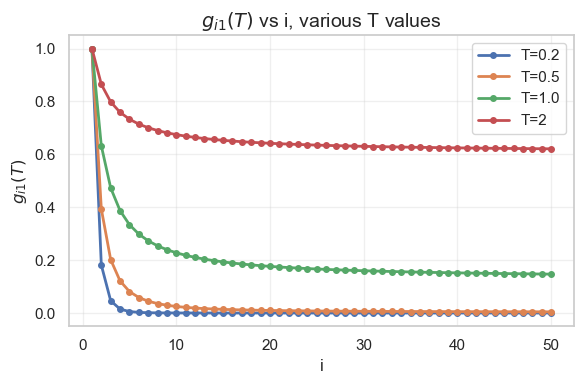

Plot saved to: C:\Users\zjmcn\OneDrive\Desktop\research\bipartition_covers\figures\g_i1_plot


In [15]:
j = 1
T_values = [0.2, 0.5, 1.0, 2]
print(f"Comparing different T values for j={j}")
plot_multiple_T_values(j, T_values, max_i=50, savepath=figures_dir / "g_i1_plot")

## Building Our Bounds

In the following sections we explore the various bounds we have developed throughout our work. 

In [16]:
T_vals = [0.1, 0.2, 0.5, 1, 2]
k_vals = range(5, 35, 5)
q = 0.99
log_plot=True
figsize=(12,4)

### Original Bound

The original paper produced a bound of the form:

$$n \geq \frac{\log\left(\frac{1-q}{k-3} \right)}{\log\left(1-g_{k-2,1}(T_{min}) \right)}$$

In [17]:
def original_bound(k, T_min, q=0.95):
    """
    Calculate the original bound:
    n >= log((1-q)/(k-3)) / log(1 - g_{k-2,1}(T_min))
    """
    if k <= 3:
        return float('inf')
    
    try:
        g_val = g_ij(k-2, 1, T_min)
        if g_val >= 1:  # Avoid log(0) or log(negative)
            return float('inf')
        
        numerator = np.log((1-q)/(k-3))
        denominator = np.log(1 - g_val)
        
        if denominator >= 0:  # log(1-g) should be negative
            return float('inf')
            
        return numerator / denominator
        
    except (ValueError, ZeroDivisionError):
        return float('inf')

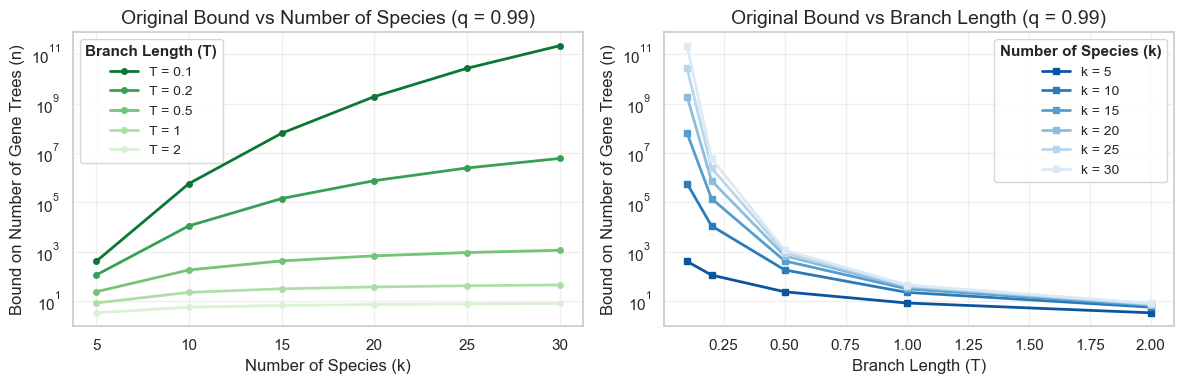

Plot saved to: C:\Users\zjmcn\OneDrive\Desktop\research\bipartition_covers\figures\original_bound.png


In [18]:
save_path = figures_dir / 'original_bound.png'
bound_name = 'Original'
_ = plot_bound(original_bound, T_vals, k_vals, q=q, make_plot=True, log_plot=log_plot, figsize=figsize, savepath=save_path, bound_name=bound_name)

### Improved Bound 1: Caterpillar Trees

My first new bound:

$$n \geq \frac{\log\left(\frac{1-q}{k-3} \right)}{\frac{1}{k-3}\sum_{\ell=2}^{k-2}\log\left(1-g_{\ell,1}(T_{min}) \right)}$$

In [20]:
def caterpillar_bound(k, T_min, q=0.95):
    """
    Calculate the improved bound:
    n >= log((1-q)/(k-3)) / (1/(k-3) * sum_{l=2}^{k-2} log(1 - g_{l,1}(T_min)))
    """
    if k <= 3:
        return float('inf')
    
    try:
        # Calculate sum of log terms
        log_sum = 0
        for ell in range(2, k-1):  # l from 2 to k-2
            g_val = g_ij(ell, 1, T_min)
            if g_val >= 1:  # Avoid log(0) or log(negative)
                return float('inf')
            log_term = np.log(1 - g_val)
            if log_term >= 0:  # Should be negative
                return float('inf')
            log_sum += log_term
        
        if log_sum == 0:  # Avoid division by zero
            return float('inf')
            
        numerator = np.log((1-q)/(k-3))
        denominator = log_sum / (k-3)
        
        if denominator >= 0:  # Should be negative
            return float('inf')
            
        return numerator / denominator
        
    except (ValueError, ZeroDivisionError):
        return float('inf')

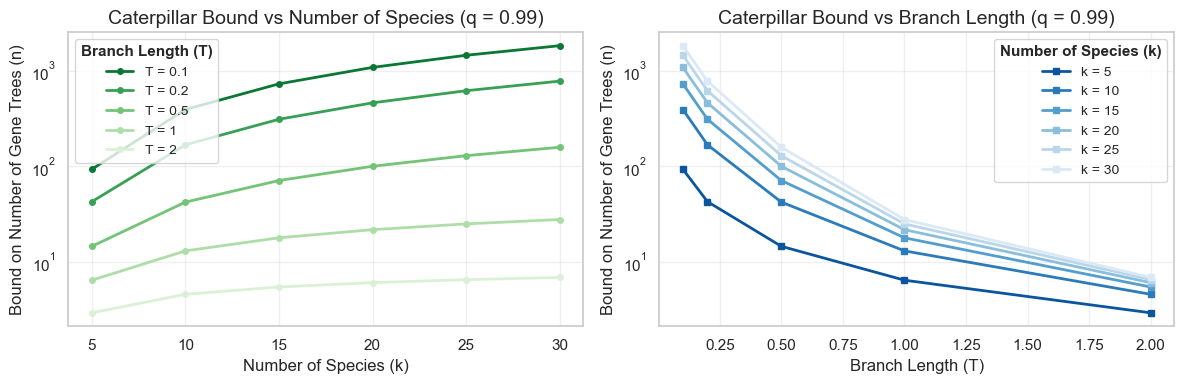

Plot saved to: C:\Users\zjmcn\OneDrive\Desktop\research\bipartition_covers\figures\caterpillar_bound.png


In [21]:
save_path = figures_dir / 'caterpillar_bound.png'
bound_name = 'Caterpillar'
_ = plot_bound(caterpillar_bound, T_vals, k_vals, q=q, make_plot=True, log_plot=log_plot, figsize=figsize, savepath=save_path, bound_name=bound_name)

### Improved Bound 2: Coalescents One-Step Down

By considering coalescent events occuring one-step below the current edge, we were able to improve the bound to:

$$ n \geq \frac{\log\left(\frac{1-q}{k-3}\right)}{\frac{1}{k-3} \sum_{\ell = 2}^{k-2}\log \left(1-q_{\ell}\right)}$$

 where for $m(\ell) := \lfloor \ell / 2\rfloor$ we define:

 $$ q_\ell := \sum_{r=1}^{m(\ell)} \sum_{s=1}^{\ell-m(\ell)} g_{m(\ell),r}(T_{min}) \cdot g_{\ell-m(\ell), s}(T_{min}) \cdot g_{r+s, 1}(T_{min})$$


In [22]:
def one_step_bound(k, T_min, q=0.95):
    """
    Calculate the improved bound:
    n >= log((1-q)/(k-3)) / (1/(k-3) * sum_{l=2}^{k-2} log(1 - q_ell))
    """
    if k <= 3:
        return float('inf')
    
    
    # Otherwise, pre-calculate all values of g_ij(T_min) we will need
    g_array = np.full((k, k), np.nan)
    for i in range(1, k):
        for j in range(1, i+1):
            g_array[i, j] = g_ij(i, j, T_min)
    
    try:
        # Calculate sum of log terms
        log_sum = 0
        for ell in range(2, k-1):  # l from 2 to k-2
            
            q_ell = 0
            
            # calculate q_ell
            m_ell = ell // 2
            for r in range(1, m_ell + 1):
                for s in range(1, ell - m_ell + 1):
                    q_ell += g_array[m_ell, r] * g_array[ell - m_ell, s] * g_array[r + s, 1]

            # Add log(1-q_ell) to running sum
            log_term = np.log(1 - q_ell)
            log_sum += log_term
        
        if log_sum == 0:  # Avoid division by zero
            return float('inf')
            
        numerator = np.log((1-q)/(k-3))
        denominator = log_sum / (k-3)
        
        if denominator >= 0:  # Should be negative
            return float('inf')
            
        return numerator / denominator
        
    except (ValueError, ZeroDivisionError):
        return float('inf')

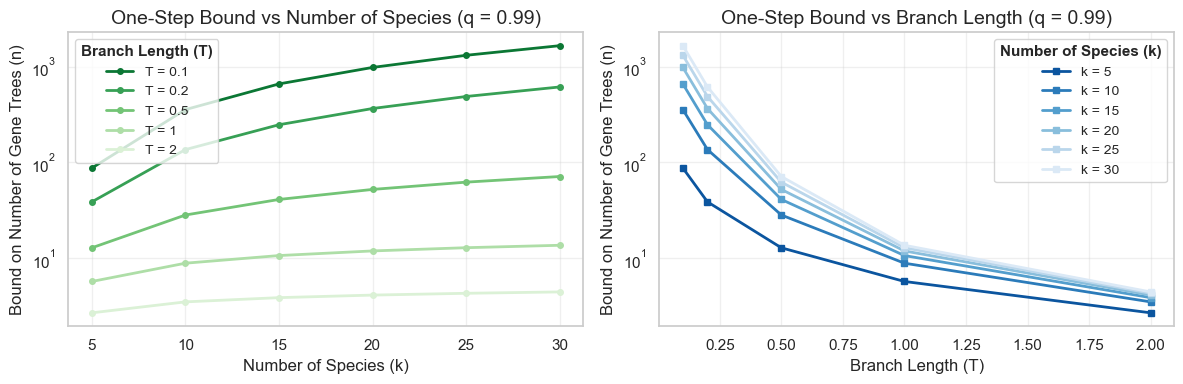

Plot saved to: C:\Users\zjmcn\OneDrive\Desktop\research\bipartition_covers\figures\one_step_bound.png


In [23]:
save_path = figures_dir / 'one_step_bound.png'
bound_name = 'One-Step'
_ = plot_bound(one_step_bound, T_vals, k_vals, q=q, make_plot=True, log_plot=log_plot, figsize=figsize, savepath=save_path, bound_name=bound_name)

### Improved Bound 3: Balanced Trees

$$n \geq \frac{\log\left(\frac{1-q}{k-3}\right)}{\frac{1}{k-3} \sum_{\ell = 2}^{k-2}\log \left(1-z_{\ell}\right)}$$

where $z_\ell := \mathbb{P}(Z_{\ell} = 1)$ and where the distributions of $Z_\ell$ are defined recursively as:

$$\mathbb{P}(Z_\ell = j) = g_{Z_{\lceil \ell/2\rceil} + Z_{\lfloor \ell/2\rfloor}', j} (T_{min}) \qquad Z_1 \equiv 1$$

|Here $Z_i'$ is an iid copy of $Z_i$ and $T_{min}$ is the minimum branch length (in coalescent units) in the species tree.

In [24]:
def balanced_bound(k, T_min, q=0.95):
    """
    Calculate the improved bound:
    n >= log((1-q)/(k-3)) / (1/(k-3) * sum_{l=2}^{k-2} log(1 - z_ell)) 
    
    as described above. 
    """
    if k <= 3:
        return float('inf')
    
 
    # Pre-calculate g_ij values: entry g[i,j] stores g_ij(T_min)
    g_array = np.full((k - 1, k - 1), 0.0)
    for i in range(1, k - 1):
        for j in range(1, i+1):
            g_array[i, j] = g_ij(i, j, T_min)
            
    # allocate space for distributions Z_i
    # z_array[i,j] = P(Z_i = j)
    z_array = np.zeros((k-1, k-1))
    
    # Set base case:
    z_array[1, 1] = 1
    
    for i in range(2, k-1):
        
        l = i // 2
        r = (i+1) // 2
        
        # calculate sum distribution
        sum_dist = np.convolve(z_array[l, :], z_array[r,:], mode='full')[:k-1]
        
        # calculate new distribution
        z_array[i, :] = sum_dist @ g_array
        

    # sanity checking 
    for i in range(1, z_array.shape[0]):
        assert np.isclose(z_array[i, :].sum(), 1.0)
        
    # calculate our bound using the calculated P(Z_i = 1) 
    try:
        # Calculate sum of log terms
        log_sum = 0
        for ell in range(2, k-1):  # l from 2 to k-2
            
            z_ell = z_array[ell, 1]

            # Add log(1-z_ell) to running sum
            log_term = np.log(1 - z_ell)
            log_sum += log_term
        
        if log_sum == 0:  # Avoid division by zero
            return float('inf')
            
        numerator = np.log((1-q)/(k-3))
        denominator = log_sum / (k-3)
        
        if denominator >= 0:  # Should be negative
            return float('inf')
            
        return numerator / denominator
        
    except (ValueError, ZeroDivisionError):
        return float('inf')

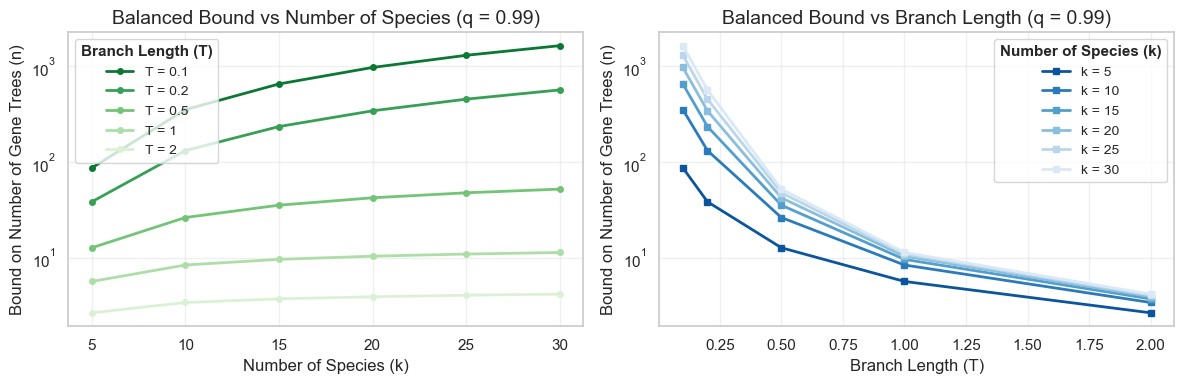

Plot saved to: C:\Users\zjmcn\OneDrive\Desktop\research\bipartition_covers\figures\balanced_bound.png


In [25]:
save_path = figures_dir / 'balanced_bound.png'
bound_name = 'Balanced'
_ = plot_bound(balanced_bound, T_vals, k_vals, q=q, make_plot=True, log_plot=log_plot, figsize=figsize, savepath=save_path, bound_name=bound_name)

## Improvement Ratios

In the following section, we compare the relative performances of our bounds.

In [16]:
# T_vals = [0.1, 0.2, 0.5, 1, 2]
# k_vals = range(5, 35, 5)
# q = 0.99
# log_plot=True
# figsize=(7,4)

### New bounds Versus Old Bounds

##### Caterpillar Bound vs Original

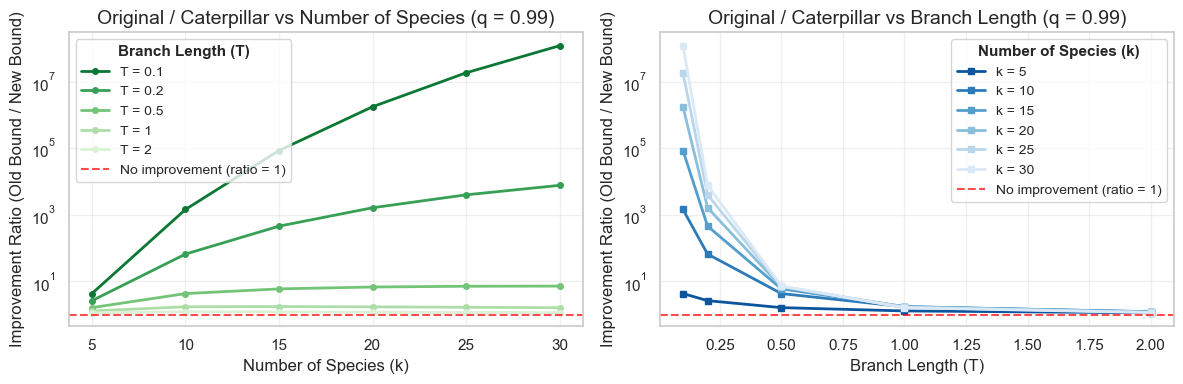

Plot saved to: C:\Users\zjmcn\OneDrive\Desktop\research\bipartition_covers\figures\cat_vs_original.png


In [30]:
save_path = figures_dir / 'cat_vs_original.png'
old_name = 'Original'
new_name = 'Caterpillar'
plot_improvement_ratio(original_bound, caterpillar_bound, T_vals, k_vals, q=q, make_plot=True, log_plot=log_plot, figsize=figsize, savepath=save_path, old_name=old_name, new_name=new_name)

##### One-Step Bound vs Original

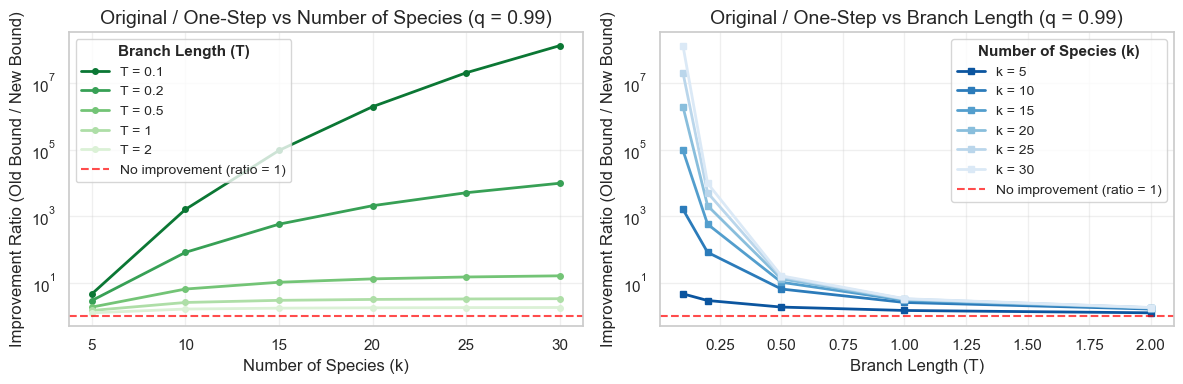

Plot saved to: C:\Users\zjmcn\OneDrive\Desktop\research\bipartition_covers\figures\onestep_vs_original.png


In [31]:
save_path = figures_dir / 'onestep_vs_original.png'
old_name = 'Original'
new_name = 'One-Step'
plot_improvement_ratio(original_bound, one_step_bound, T_vals, k_vals, q=q, make_plot=True, log_plot=log_plot, figsize=figsize, savepath=save_path, old_name=old_name, new_name=new_name)

##### Balanced vs Original

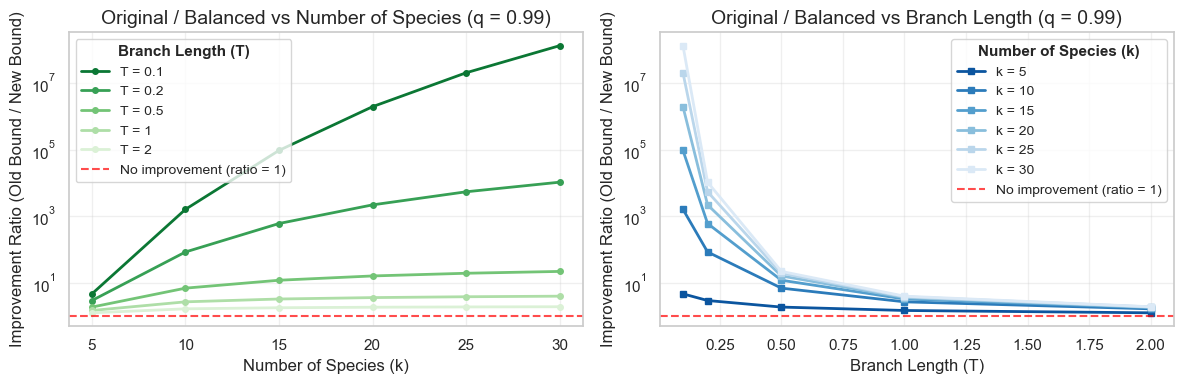

Plot saved to: C:\Users\zjmcn\OneDrive\Desktop\research\bipartition_covers\figures\balanced_vs_original.png


In [32]:
save_path = figures_dir / 'balanced_vs_original.png'
old_name = 'Original'
new_name = 'Balanced'
plot_improvement_ratio(original_bound, balanced_bound, T_vals, k_vals, q=q, make_plot=True, log_plot=log_plot, figsize=figsize,  savepath=save_path, old_name=old_name, new_name=new_name)

### New Versus New

##### Caterpillar vs One-Step

Theoretically the one-step bound should be no larger than the caterpillar bound, but let's check to what level it makes an actual improvement over the caterpillar bound. 

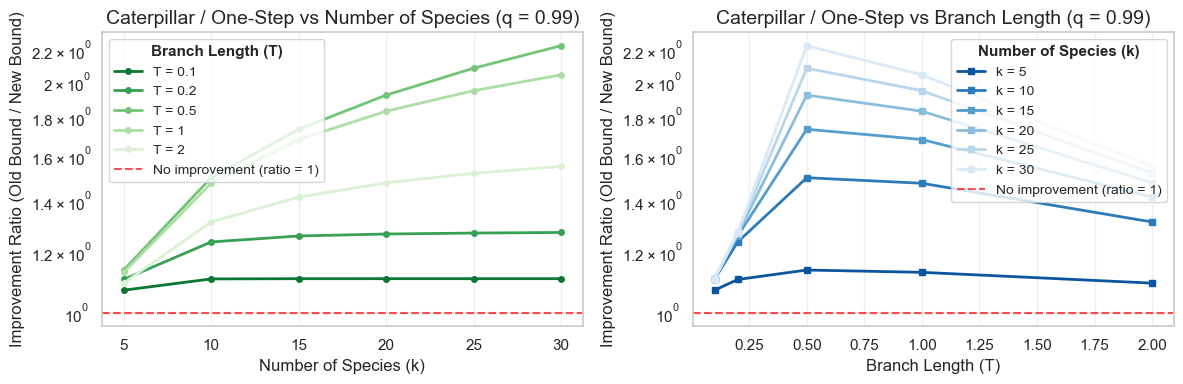

Plot saved to: C:\Users\zjmcn\OneDrive\Desktop\research\bipartition_covers\figures\one_step_vs_caterpillar.png


In [33]:
save_path = figures_dir / 'one_step_vs_caterpillar.png'
old_name = 'Caterpillar'
new_name = 'One-Step'
plot_improvement_ratio(caterpillar_bound, one_step_bound, T_vals, k_vals, q=q, make_plot=True, log_plot=log_plot, figsize=figsize, savepath=save_path, old_name=old_name, new_name=new_name)

##### Balanced vs One-Step

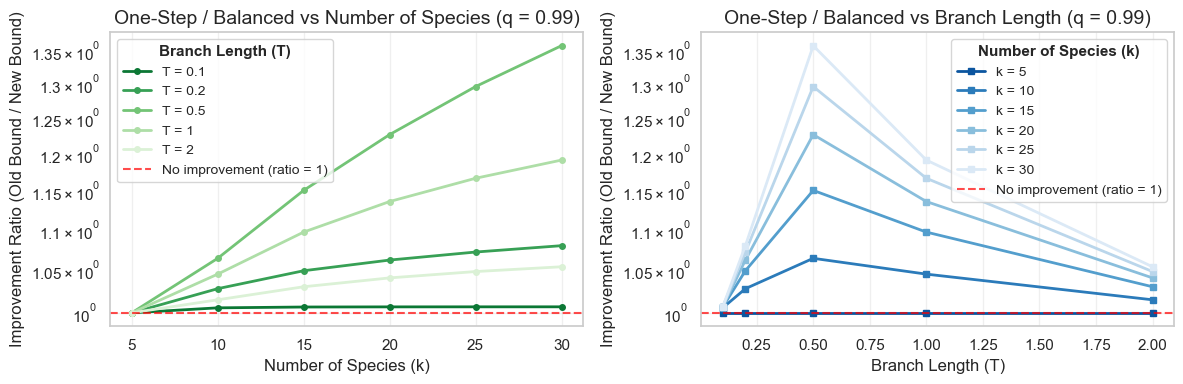

Plot saved to: C:\Users\zjmcn\OneDrive\Desktop\research\bipartition_covers\figures\balanced_vs_one_step.png


In [34]:
save_path = figures_dir / 'balanced_vs_one_step.png'
old_name = 'One-Step'
new_name = 'Balanced'
plot_improvement_ratio(one_step_bound, balanced_bound, T_vals, k_vals, q=q, make_plot=True, log_plot=log_plot, figsize=figsize, savepath=save_path, old_name=old_name, new_name=new_name)

## Gene Tree Simulations

Now we want to explore the emprical behavior of a variety of species tree topologies under the multispecies coalescent model (MSC). In particular, we are interested in studying: for a given species tree, how many gene trees are typically required until we get a bipartition cover of the species tree. We then compare these empirical results to the bounds we developed above to get a sense of how loose those bounds still are.

For this, we utilize the [Dendropy](https://jeetsukumaran.github.io/DendroPy/primer/dataobjects.html) phylogenetic package. In particular, the [Contained Coalescent](https://jeetsukumaran.github.io/DendroPy/primer/treesims.html#multispecies-coalescent-contained-coalescent-or-censored-coalescent-trees) functionality appears to be exactly what we are looking for.
* frequency_of_split: seems like this could help us check for bipartition covers.

Another candidate is [SimPhy](https://pmc.ncbi.nlm.nih.gov/articles/PMC4748750/) which may be useful for larger simulations. 

In [35]:
import dendropy
from dendropy.simulate import treesim
from dendropy import Tree, TreeList

from scipy.stats import ecdf
from tqdm import tqdm
from itertools import product

In [66]:
T_vals = [0.1, 0.2, 0.5, 1, 2] 
k_vals = [4, 8, 16, 25, 32]
num_workers = 16

num_samples = 10000#1000
max_genes= 10000
q=0.99

##### Tree generation and Sampling

In [67]:
def get_T_min(species_tree : Tree) -> float:
    '''
        Finds the minimum length of an internal branch within a species tree.
    '''
    internal_lengths = [edge.length for edge in species_tree.postorder_edge_iter() 
                   if edge.length is not None and not edge.is_terminal()]
    return min(internal_lengths)

def add_flips(bipartition_set):
    '''
        Adds the flipped versions of every bipartition when they are stored as bitmasks strings
        (e.g. AB | CD -> CD | AB is equivalent to 1100 flipping to 0011)
    '''
    mapping = {'0': '1', '1': '0'}
    flips = set()
    for x in bipartition_set:
        flipped = ''.join(mapping[char] for char in x)
        flips.add(flipped)
        
    bipartition_set.update(flips)

def sample_gene_trees_until_cover(species_tree: dendropy.Tree, num_samples=1, max_genes=1000) -> int:
    '''
        Samples gene trees from the given species_tree under the MSC model until
        we get a bipartition cover of species_tree. Repeats this process num_samples times.
        Returns a list arr where arr[i] is the number of gene trees
        required on the ith trial to get a cover, or returns np.nan if the first max_genes trees do
        not form a cover.
    '''
    # create mapping from gene names to species names; e.g. dendropy needs to know where
    # in the species tree each gene lineage begins. Since we have no gene lineage names to
    # begin with, we use this helper function to create names for the gene lineages and 
    # map them to the appropriate species.
    # genes_per_species = 1 # only one gene lineage per leaf/species
    # gene_to_species_map = dendropy.TaxonNamespaceMapping.create_contained_taxon_mapping(
    #                             containing_taxon_namespace=species_tree.taxon_namespace,
    #                             num_contained=genes_per_species)
    gene_to_species_map = {}
    for taxon in species_tree.taxon_namespace:
        gene_to_species_map[taxon] = taxon  # Map each taxon to itself
        
    gene_to_species_map = dendropy.TaxonNamespaceMapping(mapping_dict=gene_to_species_map)

    # Extract all species tree bipartitions
    species_bipartitions = species_tree.encode_bipartitions()
    
    cover_counts = np.zeros(num_samples)
    
    for trial in range(num_samples):
        
        missing_bipartitions = {str(s) for s in species_bipartitions}
        num_genes = 0

        
        while len(missing_bipartitions) > 0:
            num_genes += 1

            # cover not found in allotted time
            if num_genes > max_genes:
                cover_counts[trial] = np.nan
                break

            # Sample new gene tree (simpler approach)
            gene_tree = treesim.contained_coalescent_tree(
                containing_tree=species_tree,
                gene_to_containing_taxon_map=gene_to_species_map
            )

            # Get bipartitions from this gene tree; Since bipartitions can be
            # represented in two different ways, we add both to our collection 
            gene_bipartitions = {str(s) for s in gene_tree.encode_bipartitions()}
            add_flips(gene_bipartitions)

            # Remove any bipartitions we found from missing set
            missing_bipartitions -= gene_bipartitions

        else:
            cover_counts[trial] = num_genes
    
    return cover_counts



def plot_empirical_cdf(counts, log_plot=True):
    
    '''
        Plots the empirically observed coverage probabilities against the given
        lowerbound bound. 
        
        bound: function b(q, k, T_min) that returns the given lowerbound
    '''
    
    f = ecdf(counts)
    
    # Evaluate at specific points
    n_vals = np.arange(min(counts), max(counts)+1)
    empirical_coverage_probs = f.cdf.evaluate(n_vals)
    
    # Plot overestimation ratios
    if log_plot:
        plt.semilogy(empirical_coverage_probs, n_vals)
    else:
        plt.plot(empirical_coverage_probs, n_vals)
        
    plt.title('Emprical Coverage Probabilities')
    plt.xlabel('Probability of Cover')
    plt.ylabel('Number gene trees (n)')
    plt.legend(loc='upper left')
    plt.show()

##### Plotting 

In [68]:
def make_overestimation_plot_vs_q(species_tree_generator, bound_function, k_vals, T_vals, 
                           num_samples=100, max_genes=1000, log_plot=True, 
                           figsize=(15, 5), savepath=None, bound_name=None, tree_name=None):
    """
    Create overestimation plots comparing empirical coverage to theoretical bounds.
    
    Parameters:
    -----------
    species_tree_generator : function
        Function that takes (k, T_min) and returns a species tree
    bound_function : function  
        Function that takes (k, T_min, q) and returns theoretical bound
    k_vals : list
        List of species counts to test
    T_vals : list
        List of minimum branch lengths to test
    num_samples : int
        Number of simulation trials per (k, T_min) combination
    max_genes : int
        Maximum gene trees to sample before giving up
    log_plot : bool
        Whether to use log scale for y-axis
    figsize : tuple
        Figure size for subplots
    save_path : str, optional
        Path to save the figure
    """
    
    # Set up subplots - one for each T_min value
    fig, axes = plt.subplots(1, len(T_vals), figsize=figsize, sharey=True)
    if len(T_vals) == 1:
        axes = [axes]
    
    # Color palette for different k values
    colors = sns.color_palette("Set1", n_colors=len(k_vals))
    
    total_iterations = len(T_vals) * len(k_vals)
    with tqdm(total=total_iterations, desc="Processing combinations") as pbar:
    
        for t_idx, T_min in enumerate(T_vals):
            ax = axes[t_idx]

            for k_idx, k in enumerate(k_vals):
                pbar.set_description(f"T_min={T_min}, k={k}")
                pbar.update(1)

                # generate species tree
                species_tree = species_tree_generator(k, T_min)

                # Collect empirical data
                empirical_counts = sample_gene_trees_until_cover(species_tree, max_genes=max_genes, num_samples=num_samples)

                # Compute empirical CDF
                f = ecdf(empirical_counts)
                n_vals = np.arange(min(empirical_counts), max(empirical_counts) + 1)
                empirical_coverage_probs = f.cdf.evaluate(n_vals)

                # Calculate theoretical bounds for these probability levels
                # Use the scaling relationship to avoid recomputing bounds
                q0 = 0.5
                initial_bound = bound_function(k, T_min, q0)

                def scaled_bound(q):
                    return initial_bound * np.log((1-q) / (k-3)) / np.log((1-q0) / (k-3))

                # Filter out q values too close to 1
                valid_mask = empirical_coverage_probs < 0.999
                q_vals = empirical_coverage_probs[valid_mask]
                n_vals_valid = n_vals[valid_mask]

                theoretical_bounds = scaled_bound(q_vals)

                # Compute overestimation ratios
                overestimate_ratios = theoretical_bounds / n_vals_valid

                # Plot
                if log_plot:
                    ax.semilogy(q_vals, overestimate_ratios, 
                               color=colors[k_idx], marker='o', markersize=3,
                               label=f'k = {k}', linewidth=2)
                else:
                    ax.plot(q_vals, overestimate_ratios, 
                           color=colors[k_idx], marker='o', markersize=3,
                           label=f'k = {k}', linewidth=2)

            # Add horizontal line at ratio = 1 (perfect prediction)
            ax.axhline(y=1, color='black', linestyle='--', alpha=0.5, linewidth=1)

            # Customize subplot
            ax.set_xlabel('Probability (q)', fontsize=12)
            ax.set_title(f'$T_{{min}} = {T_min}$', fontsize=14)
            ax.grid(True, alpha=0.3)
            ax.set_xlim(0, 1)

            # Add legend to rightmost plot
            if t_idx == len(T_vals) - 1:
                ax.legend(title='Species', bbox_to_anchor=(1.05, 1), loc='upper left')
                

        # Set y-label on leftmost plot
    axes[0].set_ylabel('$n_b / n_s$', fontsize=12)
    
    # Overall title
    if bound_name is None or tree_name is None:
        fig.suptitle('Bound Overestimation vs Empirical Coverage Probabilities', fontsize=16, y=0.98)
    else:
        fig.suptitle(f'{bound_name} Bound Overestimation for {tree_name} Trees', fontsize=16, y=0.98)
        
    
    plt.tight_layout()
    
    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches='tight')
        print(f"Plot saved to: {savepath}")
    
    plt.show()

In [69]:
def make_overestimation_plot_vs_T_k(species_tree_generator, bound_function, k_vals, T_vals, q=0.95,
                           num_samples=100, max_genes=1000, log_plot=True, 
                           figsize=(15, 5), savepath=None, bound_name=None, tree_name=None):
    """
    Create overestimation plots comparing empirical coverage to theoretical bounds. Plots over-estimation
    for the given quantile q.
    
    Parameters:
    -----------
    species_tree_generator : function
        Function that takes (k, T_min) and returns a species tree
    bound_function : function  
        Function that takes (k, T_min, q) and returns theoretical bound
    k_vals : list
        List of species counts to test
    T_vals : list
        List of minimum branch lengths to test
    num_samples : int
        Number of simulation trials per (k, T_min) combination
    max_genes : int
        Maximum gene trees to sample before giving up
    log_plot : bool
        Whether to use log scale for y-axis
    figsize : tuple
        Figure size for subplots
    save_path : str, optional
        Path to save the figure
    """
    
    # Set up subplots - one for each T_min value
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)
    if len(T_vals) == 1:
        axes = [axes]
    
    # Color palette for different k values
    colors = sns.color_palette("Set1", n_colors=len(k_vals))
    
    total_iterations = len(T_vals) * len(k_vals)
    results = []
    
    with tqdm(total=total_iterations, desc="Processing combinations") as pbar:
    
        for t_idx, T_min in enumerate(T_vals):
            for k_idx, k in enumerate(k_vals):
                pbar.set_description(f"T_min={T_min}, k={k}")
                pbar.update(1)

                # generate species tree
                species_tree = species_tree_generator(k, T_min)

                # Collect empirical data
                empirical_counts = sample_gene_trees_until_cover(species_tree, max_genes=max_genes, num_samples=num_samples)

                # Compute empirical quantile
                empirical_quantile = np.quantile(empirical_counts, q)

                # Calculate theoretical bounds for these probability levels
                theoretical_bound = bound_function(k, T_min, q=q)

                # Compute overestimation ratios
                overestimation_ratio = theoretical_bound / empirical_quantile

                results.append({
                    'k': k, 
                    'T': T_min, 
                    'theoretical': theoretical_bound,
                    'empirical': empirical_quantile,
                    'overestimation_ratio': overestimation_ratio
                })
 
    # Convert to DataFrame
    df = pd.DataFrame(results)
    
    # Set up the plot style
    sns.set_style("whitegrid")

    # Plot as function of k ##################################################
    ax = axes[0]
    
    # Create green color palette - darker for larger T values (longer times)
    # Reverse the palette so smaller T values are lighter
    colors = sns.color_palette("Greens", n_colors=len(T_vals))
    colors = colors[::-1]  # Reverse so smaller T (shorter times) are lighter

    # Plot each T value as a separate line
    for i, T in enumerate(T_vals):
        T_data = df[df['T'] == T]

        if log_plot:
            ax.semilogy(T_data['k'], T_data['overestimation_ratio'], 
                       color=colors[i], linewidth=2, marker='o', markersize=4,
                       label=f'T = {T}')
        else:
            ax.plot(T_data['k'], T_data['overestimation_ratio'], 
                    color=colors[i], linewidth=2, marker='o', markersize=4,
                    label=f'T = {T}')

    # Add horizontal line at y=1 to show "no improvement" baseline
    ax.axhline(y=1, color='red', linestyle='--', alpha=0.7, 
               label='No Overestimation (ratio = 1)')

    # Customize the plot
    ax.set_xlabel('Number of Species (k)', fontsize=12)
    ax.set_ylabel('Overestimation Ratio (Old Bound / New Bound)', fontsize=12)
    #ax.set_title(f'Bound Overestimation Ratio vs Number of Species (q = {q})', fontsize=14)


    # Add legend with custom styling
    legend = ax.legend(title='Branch Length (T)', title_fontsize=11, 
                      fontsize=10, loc='upper left')
    legend.get_title().set_fontweight('bold')

    # Set grid and layout
    ax.grid(True, alpha=0.3)

    # Plot as function of T ###################################
    ax = axes[1]

    # Create a different color palette for k values (use blues to distinguish from greens)
    k_colors = sns.color_palette("Blues", n_colors=len(k_vals))
    k_colors = k_colors[::-1]  # Reverse so smaller k values are lighter

    # Plot each k value as a separate line
    for i, k in enumerate(k_vals):
        k_data = df[df['k'] == k]

        if log_plot:
            ax.semilogy(k_data['T'], k_data['overestimation_ratio'], 
                       color=k_colors[i], linewidth=2, marker='s', markersize=4,
                       label=f'k = {k}')
        else:
            ax.plot(k_data['T'], k_data['overestimation_ratio'], 
                    color=k_colors[i], linewidth=2, marker='s', markersize=4,
                    label=f'k = {k}')

    # Add horizontal line at y=1 to show "no improvement" baseline
    ax.axhline(y=1, color='red', linestyle='--', alpha=0.7, 
               label='No Overestimation (ratio = 1)')

    # Customize the plot
    ax.set_xlabel('Branch Length (T)', fontsize=12)
    ax.set_ylabel('Overestimation Ratio (Old Bound / New Bound)', fontsize=12)
    #ax.set_title(f'Bound Overestimation Ratio vs Branch Length (q = {q})', fontsize=14)

    # Add legend with custom styling
    legend = ax.legend(title='Number of Species (k)', title_fontsize=11, 
                      fontsize=10, loc='upper right')
    legend.get_title().set_fontweight('bold')

    # Set grid and layout
    ax.grid(True, alpha=0.3)
    
    # Overall title
    if bound_name is None or tree_name is None:
        fig.suptitle('Bound Overestimation vs Empirical Coverage Probabilities', fontsize=16, y=0.95)
    else:
        fig.suptitle(f'{bound_name} Bound Overestimation for {tree_name} Trees', fontsize=16, y=0.95)

    plt.tight_layout()
    plt.show()

                    # Save plot if path provided
    if savepath:
        fig.savefig(savepath, dpi=600, bbox_inches='tight')
        plt.close(fig)
        print(f"Plot saved to: {savepath}")

### Caterpillar and Balanced Trees

We saw in our paper's analysis that balanced trees and caterpillar trees, where all the branch lengths were equal to $T_{min}$, were in some sense the worst-case when it comes to our bounds. Hence, these are the trees we expect our bounds to be the most tight on.  

In [70]:
def create_caterpillar_tree(k, branch_length=1.0):
    """Create a caterpillar tree with k taxa"""
    taxa = [f"T{i}" for i in range(k)]
    taxon_namespace = dendropy.TaxonNamespace(taxa)
    
    # Build newick string for caterpillar: ((((T0,T1),T2),T3),T4)
    newick = taxa[0]
    for i in range(1, k):
        newick = f"({newick},{taxa[i]}):{branch_length}"
    newick += ";"
    
    tree = dendropy.Tree.get(data=newick, schema="newick", 
                           taxon_namespace=taxon_namespace)
    return tree

def build_balanced_newick(taxon_list, branch_length):
    
    '''
        Helper method for create_balanced_tree
    '''
    if len(taxon_list) == 1:
        return taxon_list[0]
    elif len(taxon_list) == 2:
        return f"({taxon_list[0]}:{branch_length},{taxon_list[1]}:{branch_length})"
    else:
        mid = len(taxon_list) // 2
        left = build_balanced_newick(taxon_list[:mid], branch_length)
        right = build_balanced_newick(taxon_list[mid:], branch_length)
        return f"({left},{right}):{branch_length}"

    
def create_balanced_tree(k, branch_length=1.0):
    """Create a balanced tree with k taxa (works best when k is power of 2)"""
    if k == 1:
        return dendropy.Tree.get(data="T0;", schema="newick")
    
    taxa = [f"T{i}" for i in range(k)]

    newick = build_balanced_newick(taxa, branch_length) + ";"
    tree = dendropy.Tree.get(data=newick, schema="newick")
    return tree

##### Caterpillar Tree

In [71]:
num_species = 8
T_min = 1

c_tree = create_caterpillar_tree(num_species, T_min)
print(f'Caterpillar tree (T_min = {get_T_min(c_tree)})')
c_tree.print_plot()

Caterpillar tree (T_min = 1.0)
                                                                                                  /--------------- T0 
                                                                                  /---------------+                   
                                                                 /----------------+               \--------------- T1 
                                                                 |                |                                   
                                                 /---------------+                \------------------------------- T2 
                                                 |               |                                                    
                                /----------------+               \------------------------------------------------ T3 
                                |                |                                                                    
                /

Results for Bound Original


T_min=2, k=32: 100%|████████████████████████████████████████████████████████████████| 25/25 [1:09:47<00:00, 167.52s/it]


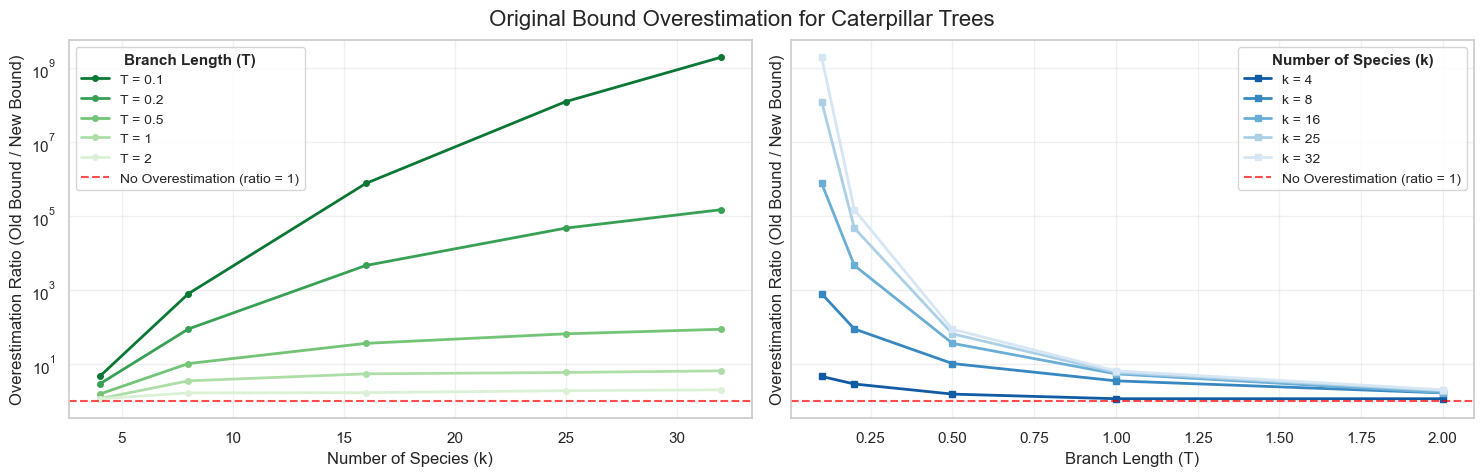

Plot saved to: C:\Users\zjmcn\OneDrive\Desktop\research\bipartition_covers\figures\overestimation_ratios\caterpillar_tree_Original_bound_vs_T_k.png


T_min=1, k=32: 100%|███████████████████████████████████████████████████████████████████| 15/15 [17:52<00:00, 71.49s/it]


Plot saved to: C:\Users\zjmcn\OneDrive\Desktop\research\bipartition_covers\figures\overestimation_ratios\caterpillar_tree_Original_bound_vs_q.png


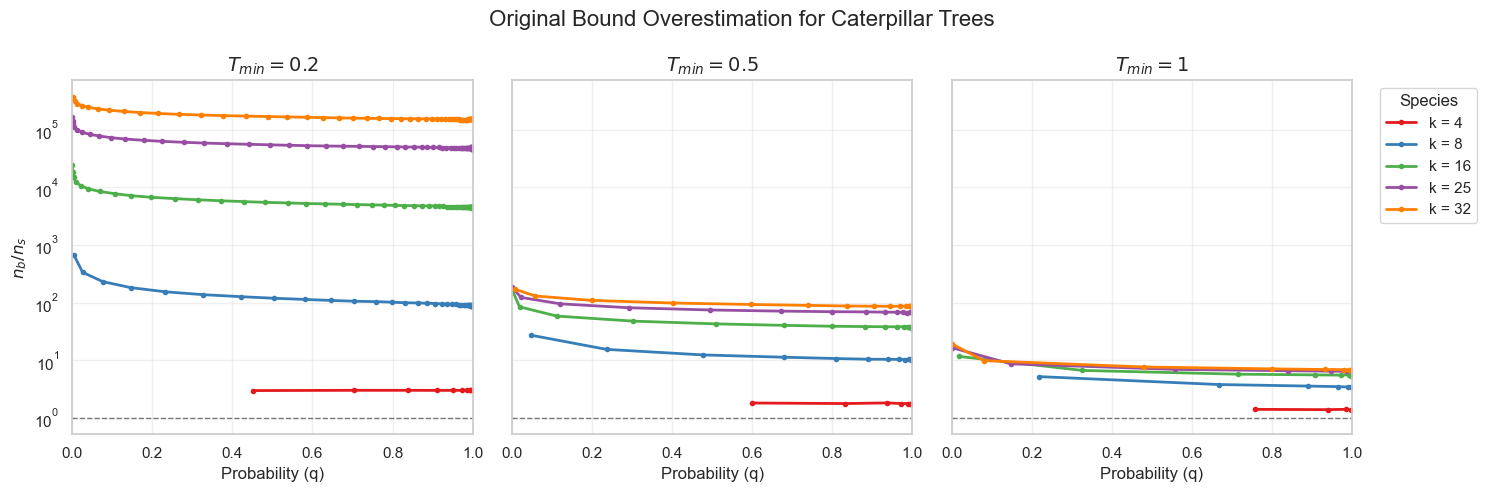

Results for Bound Caterpillar


T_min=2, k=32: 100%|████████████████████████████████████████████████████████████████| 25/25 [1:08:56<00:00, 165.44s/it]


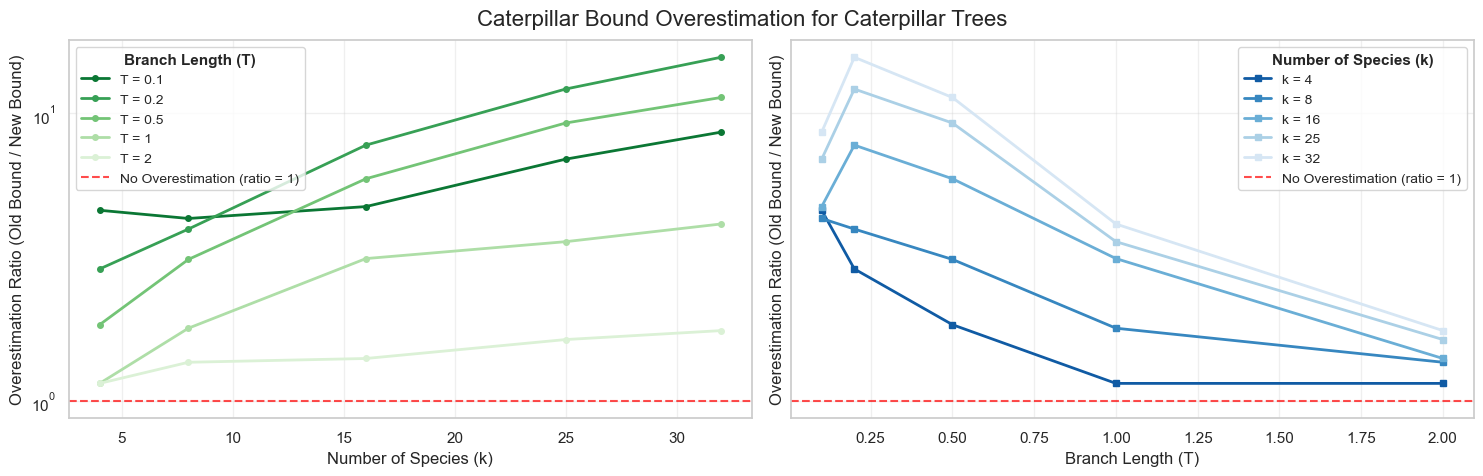

Plot saved to: C:\Users\zjmcn\OneDrive\Desktop\research\bipartition_covers\figures\overestimation_ratios\caterpillar_tree_Caterpillar_bound_vs_T_k.png


T_min=1, k=32: 100%|███████████████████████████████████████████████████████████████████| 15/15 [17:57<00:00, 71.81s/it]


Plot saved to: C:\Users\zjmcn\OneDrive\Desktop\research\bipartition_covers\figures\overestimation_ratios\caterpillar_tree_Caterpillar_bound_vs_q.png


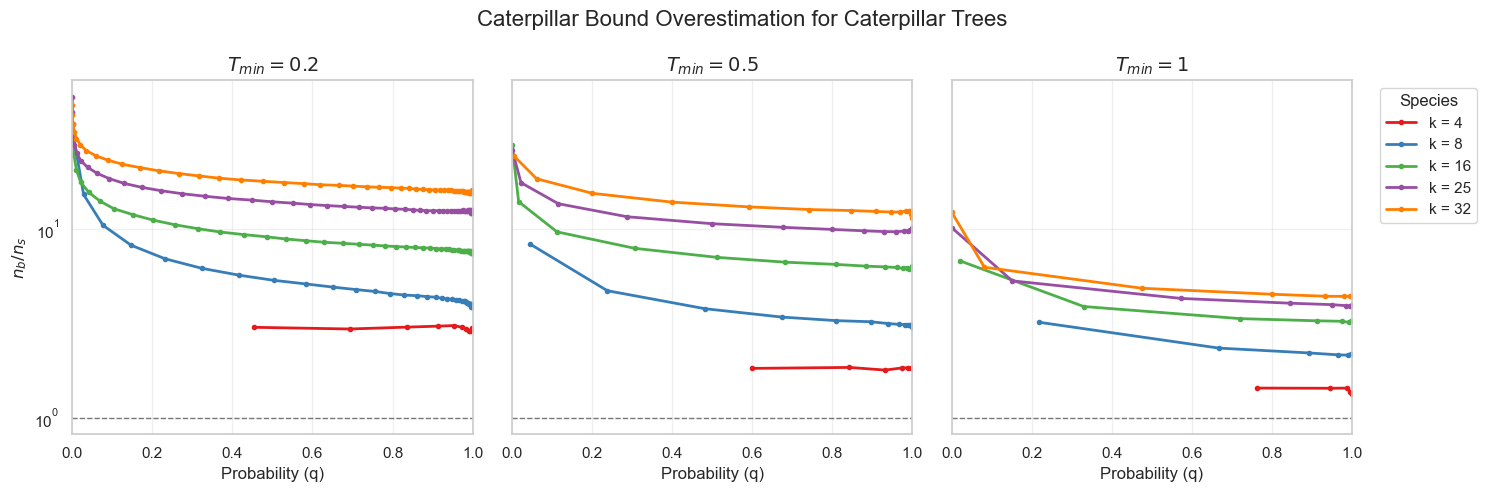

Results for Bound Balanced


T_min=2, k=32: 100%|████████████████████████████████████████████████████████████████| 25/25 [1:09:02<00:00, 165.69s/it]


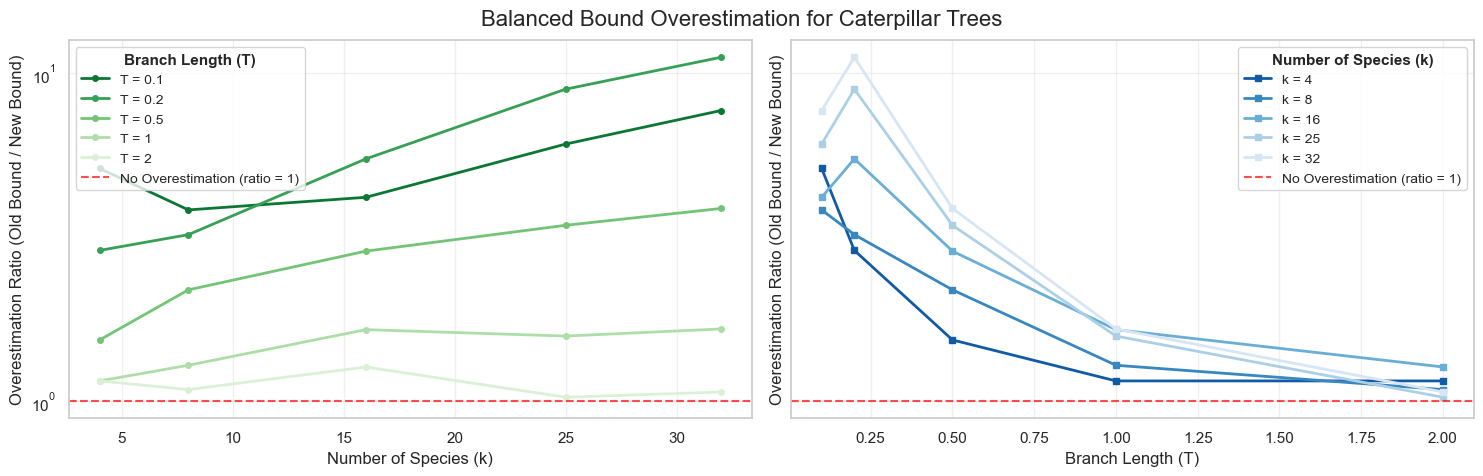

Plot saved to: C:\Users\zjmcn\OneDrive\Desktop\research\bipartition_covers\figures\overestimation_ratios\caterpillar_tree_Balanced_bound_vs_T_k.png


T_min=1, k=32: 100%|███████████████████████████████████████████████████████████████████| 15/15 [19:06<00:00, 76.43s/it]


Plot saved to: C:\Users\zjmcn\OneDrive\Desktop\research\bipartition_covers\figures\overestimation_ratios\caterpillar_tree_Balanced_bound_vs_q.png


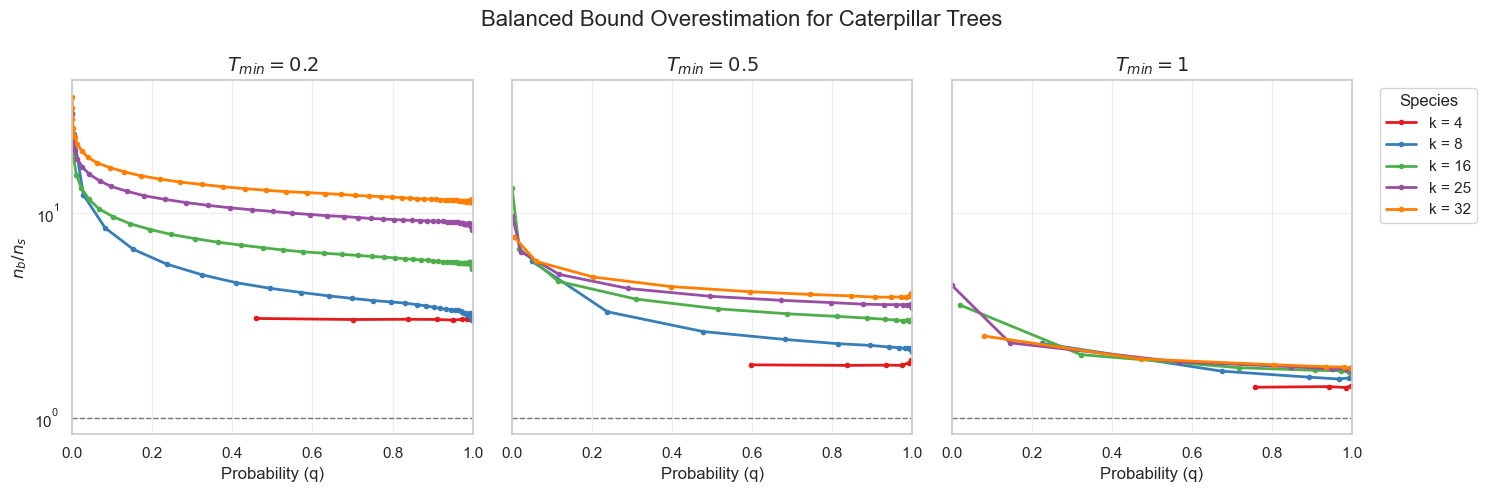

In [72]:
all_bounds = [original_bound, caterpillar_bound, balanced_bound]
names = ['Original', 'Caterpillar', 'Balanced']
for name, bound in zip(names, all_bounds):
    print(f'Results for Bound {name}')
    savepath = figures_dir / 'overestimation_ratios' / f'caterpillar_tree_{name}_bound_vs_T_k.png'
    make_overestimation_plot_vs_T_k(create_caterpillar_tree, bound, k_vals, T_vals, 
                               num_samples=num_samples, max_genes=max_genes, log_plot=True, 
                               q = q,
                               figsize=(15, 5), savepath=savepath,
                               bound_name=name, tree_name='Caterpillar')
    savepath = figures_dir / 'overestimation_ratios' / f'caterpillar_tree_{name}_bound_vs_q.png'
    make_overestimation_plot_vs_q(create_caterpillar_tree, bound, k_vals, [0.2, 0.5, 1], 
                           num_samples=num_samples, max_genes=max_genes, log_plot=True, 
                           figsize=(15, 5), savepath=savepath,
                               bound_name=name, tree_name='Caterpillar')

##### Balanced Tree

In [145]:
bal_tree = create_balanced_tree(num_species, T_min)
print('Balanced Tree')
bal_tree.print_plot()

Balanced Tree
                                                                            /-------------------------------------- T0
                                      /-------------------------------------+                                         
                                      |                                     \-------------------------------------- T1
/-------------------------------------+                                                                               
|                                     |                                     /-------------------------------------- T2
|                                     \-------------------------------------+                                         
|                                                                           \-------------------------------------- T3
+                                                                                                                     
|                                 

Results for Bound original


T_min=2, k=64: 100%|████████████████████████████████████████████████████████████████| 40/40 [3:11:06<00:00, 286.66s/it]


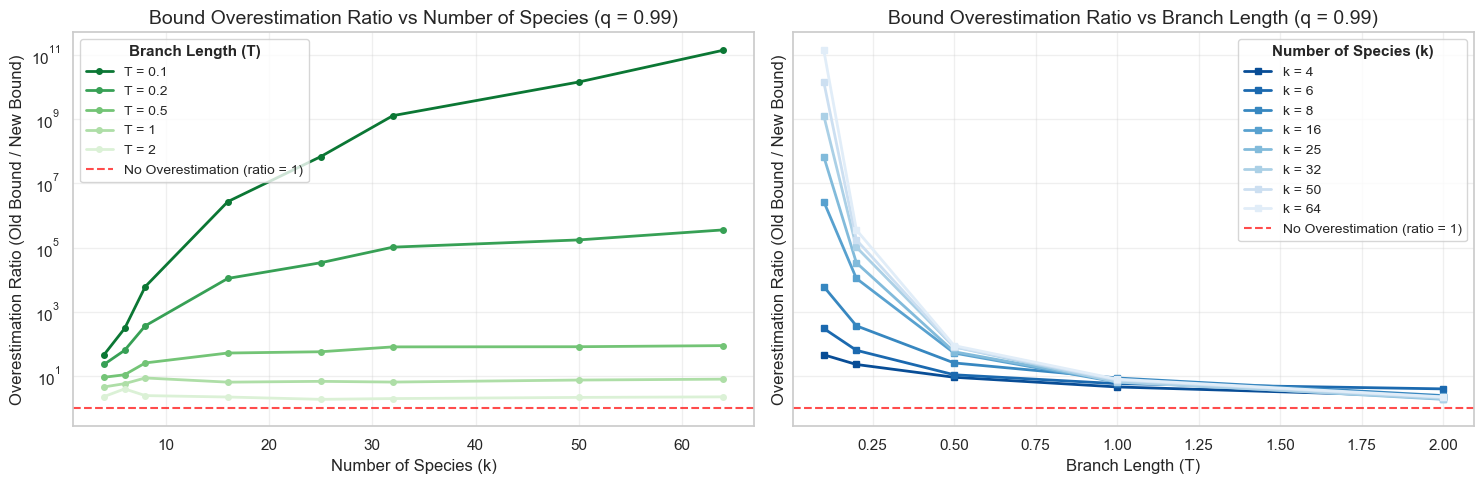

Plot saved to: C:\Users\zjmcn\OneDrive\Desktop\research\bipartition_covers\figures\overestimation_ratios\balanced_tree_original_bound_vs_T_k.png


T_min=1, k=64: 100%|███████████████████████████████████████████████████████████████████| 24/24 [18:43<00:00, 46.80s/it]


Plot saved to: C:\Users\zjmcn\OneDrive\Desktop\research\bipartition_covers\figures\overestimation_ratios\balanced_tree_original_bound_vs_q.png


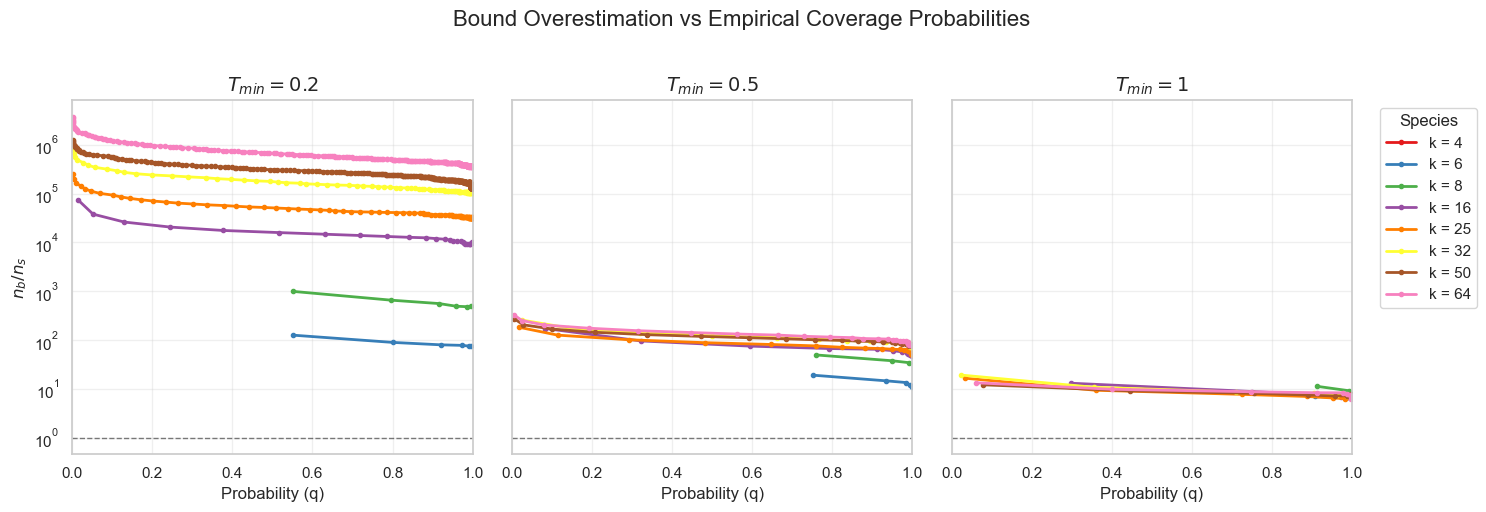

Results for Bound caterpillar


T_min=2, k=64: 100%|████████████████████████████████████████████████████████████████| 40/40 [2:58:43<00:00, 268.09s/it]


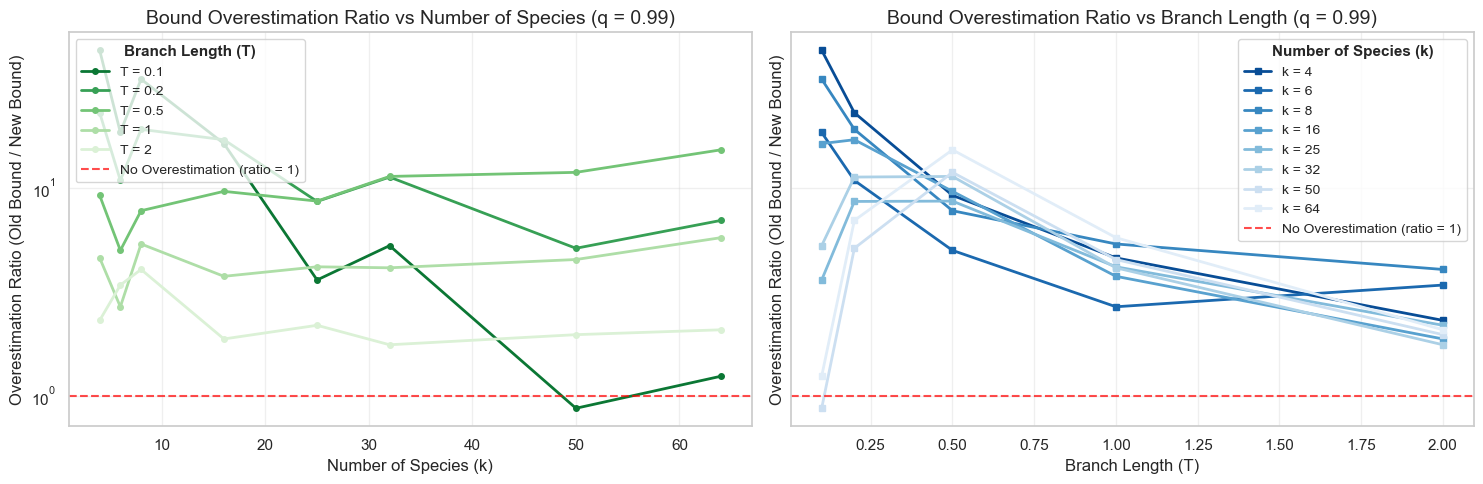

Plot saved to: C:\Users\zjmcn\OneDrive\Desktop\research\bipartition_covers\figures\overestimation_ratios\balanced_tree_caterpillar_bound_vs_T_k.png


T_min=1, k=64: 100%|███████████████████████████████████████████████████████████████████| 24/24 [14:19<00:00, 35.82s/it]


Plot saved to: C:\Users\zjmcn\OneDrive\Desktop\research\bipartition_covers\figures\overestimation_ratios\balanced_tree_caterpillar_bound_vs_q.png


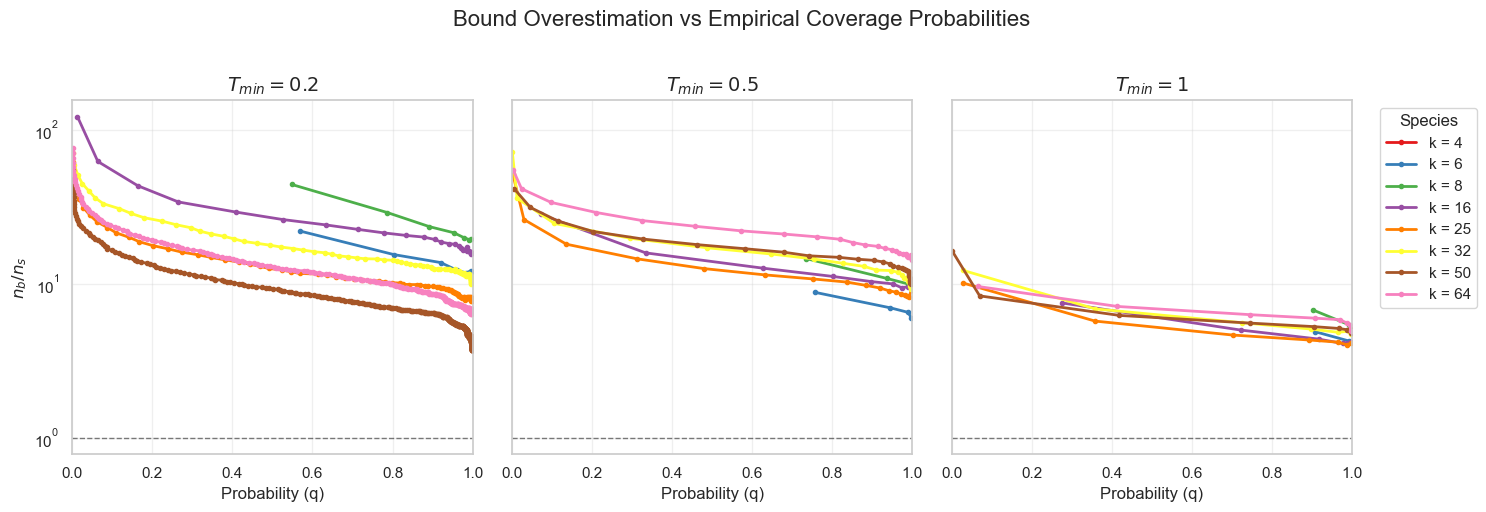

Results for Bound balanced


T_min=2, k=64: 100%|████████████████████████████████████████████████████████████████| 40/40 [7:39:47<00:00, 689.69s/it]


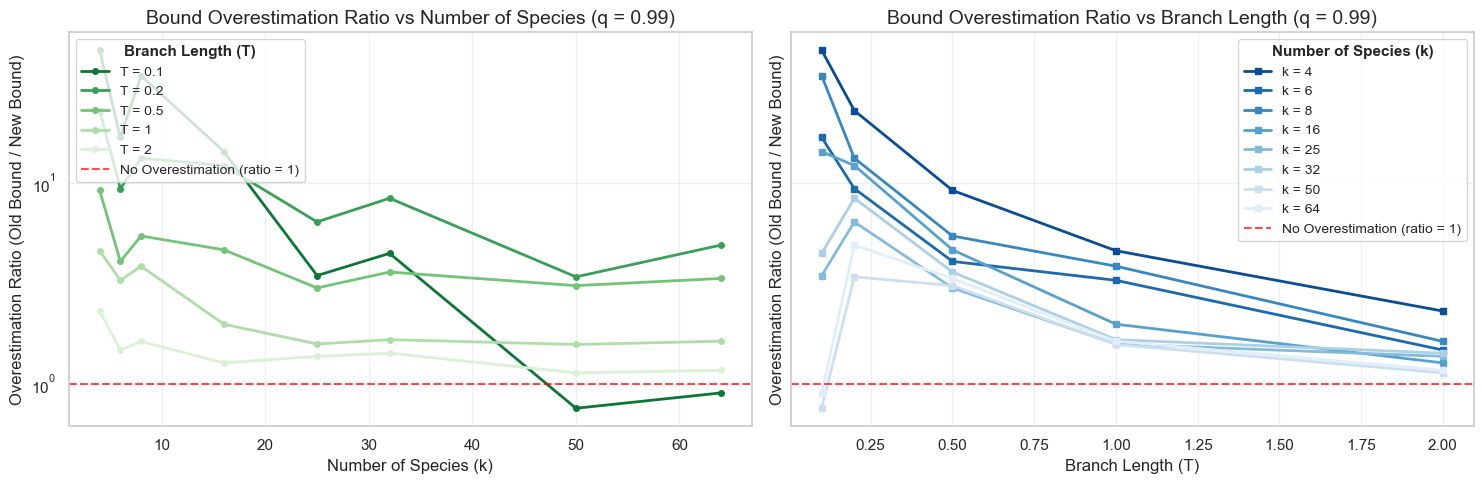

Plot saved to: C:\Users\zjmcn\OneDrive\Desktop\research\bipartition_covers\figures\overestimation_ratios\balanced_tree_balanced_bound_vs_T_k.png


T_min=1, k=64: 100%|███████████████████████████████████████████████████████████████████| 24/24 [15:02<00:00, 37.62s/it]


Plot saved to: C:\Users\zjmcn\OneDrive\Desktop\research\bipartition_covers\figures\overestimation_ratios\balanced_tree_balanced_bound_vs_q.png


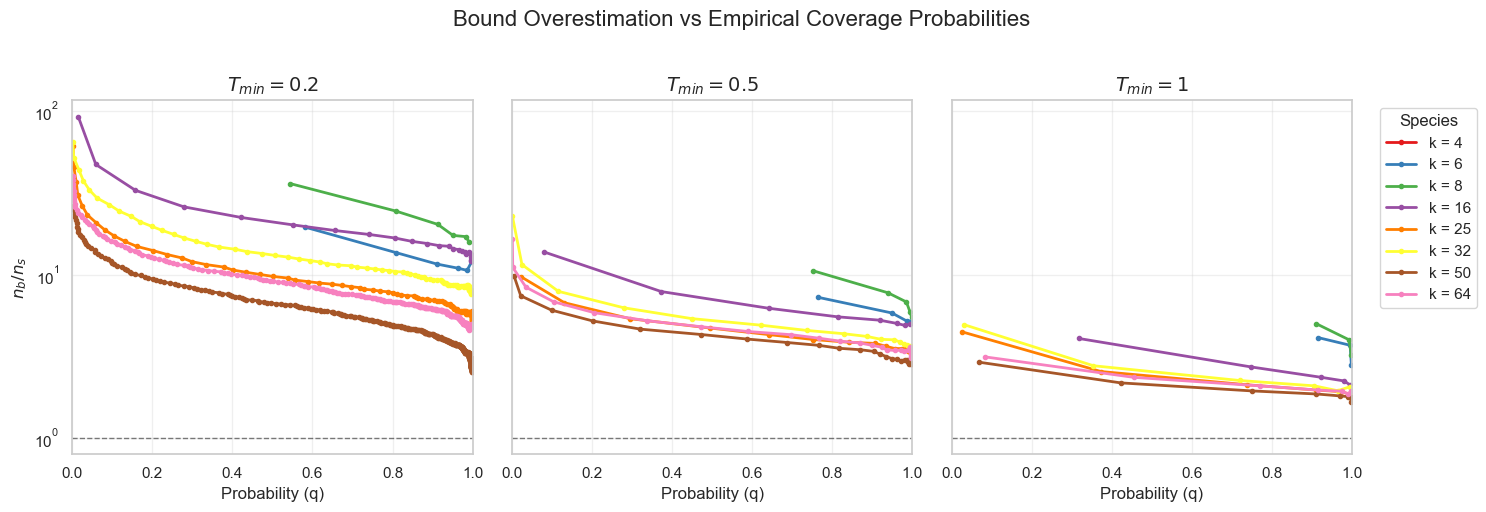

In [146]:
for name, bound in zip(names, all_bounds):
    print(f'Results for Bound {name}')
    savepath = figures_dir / 'overestimation_ratios' / f'balanced_tree_{name}_bound_vs_T_k.png'
    make_overestimation_plot_vs_T_k(create_balanced_tree, bound, k_vals, T_vals, 
                               num_samples=num_samples, max_genes=max_genes, log_plot=True, 
                               q = q,
                               figsize=(15, 5), savepath=savepath,
                               bound_name=name, tree_name='Balanced')
    savepath = figures_dir / 'overestimation_ratios' / f'balanced_tree_{name}_bound_vs_q.png'
    make_overestimation_plot_vs_q(create_balanced_tree, bound, k_vals, [0.2, 0.5, 1], 
                           num_samples=num_samples, max_genes=max_genes, log_plot=True, 
                           figsize=(15, 5), savepath=savepath,
                            bound_name=name, tree_name='Balanced')

### Yule Trees

The Yule model is a simple birth-death process (with no death; e.g. a pure birth process). To generate a species tree under the Yule model, we start with a single population. Then, each existing population splits in two at rate $\lambda$ where $\lambda$ is our birth-rate parameter. This continues until the desired number of species/populations/leaves are produced. Each internal branch in such a tree then has length $\exp(2\lambda)$. 

If we have $k$ species, since we have $k-2$ internal edges within our tree this means the minimum internal branch length is on the order $\frac{1}{2(k-2)\lambda}$

In [147]:
def create_yule_tree(num_species, T_min):
    '''
        Generates a tree under the Yule model, but renormalizes the edge lengths so that the 
        minimum length is T_min. 
    '''
    yule_tree = treesim.birth_death_tree(
    birth_rate=birth_rate, 
    death_rate=0.0, 
    num_extant_tips=num_species
    )
    
    T = get_T_min(yule_tree)
    for edge in yule_tree.postorder_edge_iter():
        edge.length *= T_min/T
        
    return yule_tree

In [148]:
birth_rate = 1
num_species = 20

# Generate species tree under Yule (birth-death) process
yule_tree = treesim.birth_death_tree(
    birth_rate=birth_rate, 
    death_rate=0.0, 
    num_extant_tips=num_species
)

# Find minimal length internal branch (exclude terminal/leaf branches)
T_min = get_T_min(yule_tree)
print('Minimal branch length: ', T_min) 

if num_species <= 20:
    yule_tree.print_plot()

Minimal branch length:  0.030149986719828593
                                                                                                 /---------------- T2 
/------------------------------------------------------------------------------------------------+                    
|                                                                                                \---------------- T11
|                                                                                                                     
|                               /--------------------------------------------------------------------------------- T6 
|                               |                                                                                     
|                               |                                                /-------------------------------- T10
|                               |                                /---------------+                                    
|  

Now that we have generated our species tree, we can sample gene trees from the model.

In [149]:
# Now let's simulate many gene trees from such a model.
yule_counts = sample_gene_trees_until_cover(yule_tree, num_samples=1000)
yule_counts[:5]

array([ 5., 12., 17., 14., 18.])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


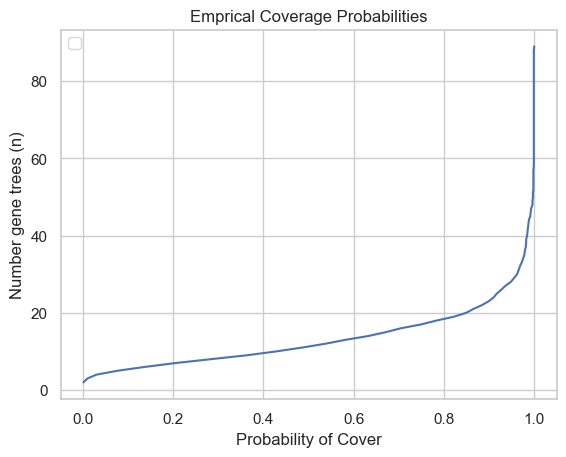

In [150]:
plot_empirical_cdf(yule_counts, log_plot=False)

Results for Bound original


T_min=2, k=64: 100%|███████████████████████████████████████████████████████████████████| 40/40 [02:26<00:00,  3.67s/it]


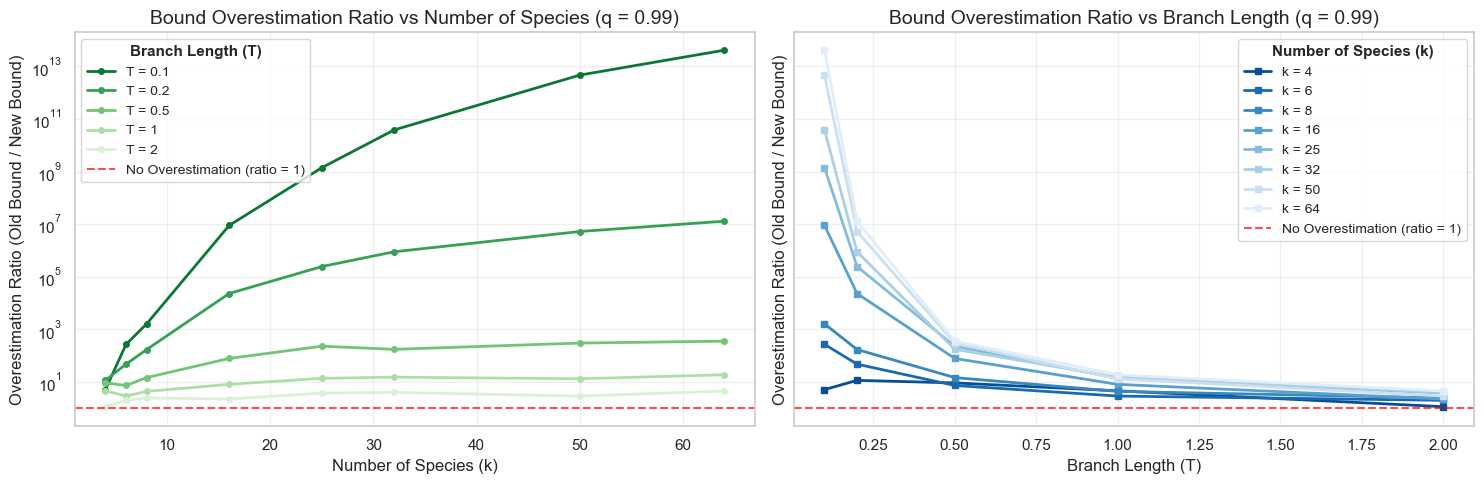

Plot saved to: C:\Users\zjmcn\OneDrive\Desktop\research\bipartition_covers\figures\overestimation_ratios\yule_tree_original_bound_vs_T_k.png


T_min=1, k=64: 100%|███████████████████████████████████████████████████████████████████| 24/24 [01:28<00:00,  3.67s/it]


Plot saved to: C:\Users\zjmcn\OneDrive\Desktop\research\bipartition_covers\figures\overestimation_ratios\yule_tree_original_bound_vs_q.png


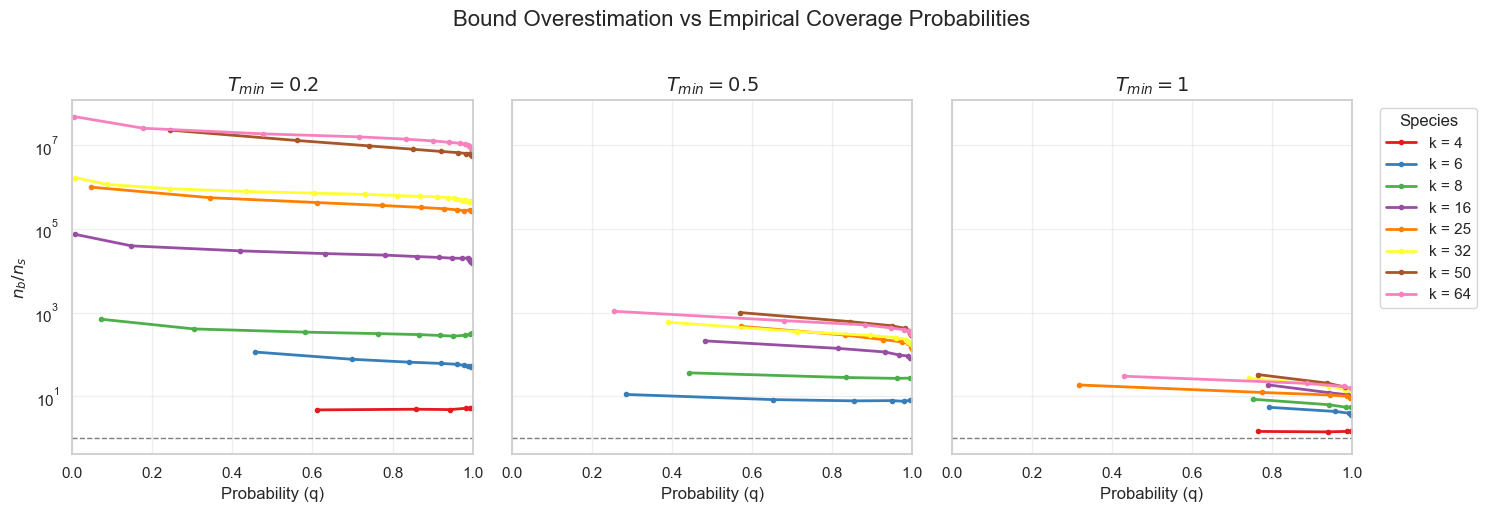

Results for Bound caterpillar


T_min=2, k=64: 100%|███████████████████████████████████████████████████████████████████| 40/40 [02:28<00:00,  3.72s/it]


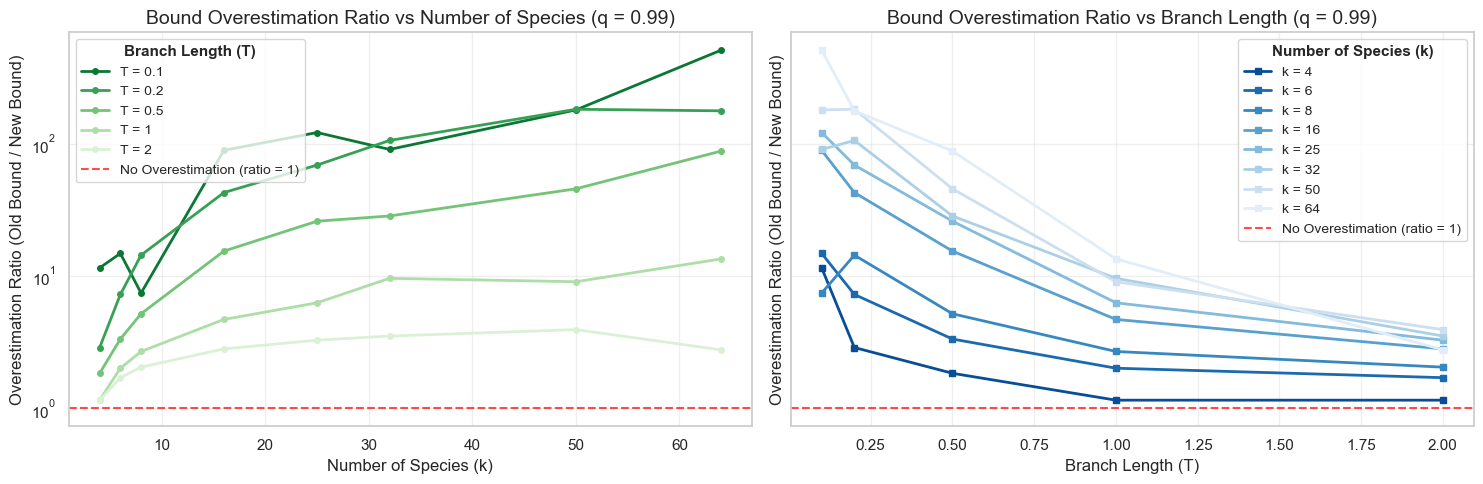

Plot saved to: C:\Users\zjmcn\OneDrive\Desktop\research\bipartition_covers\figures\overestimation_ratios\yule_tree_caterpillar_bound_vs_T_k.png


T_min=1, k=64: 100%|███████████████████████████████████████████████████████████████████| 24/24 [01:23<00:00,  3.48s/it]


Plot saved to: C:\Users\zjmcn\OneDrive\Desktop\research\bipartition_covers\figures\overestimation_ratios\yule_tree_caterpillar_bound_vs_q.png


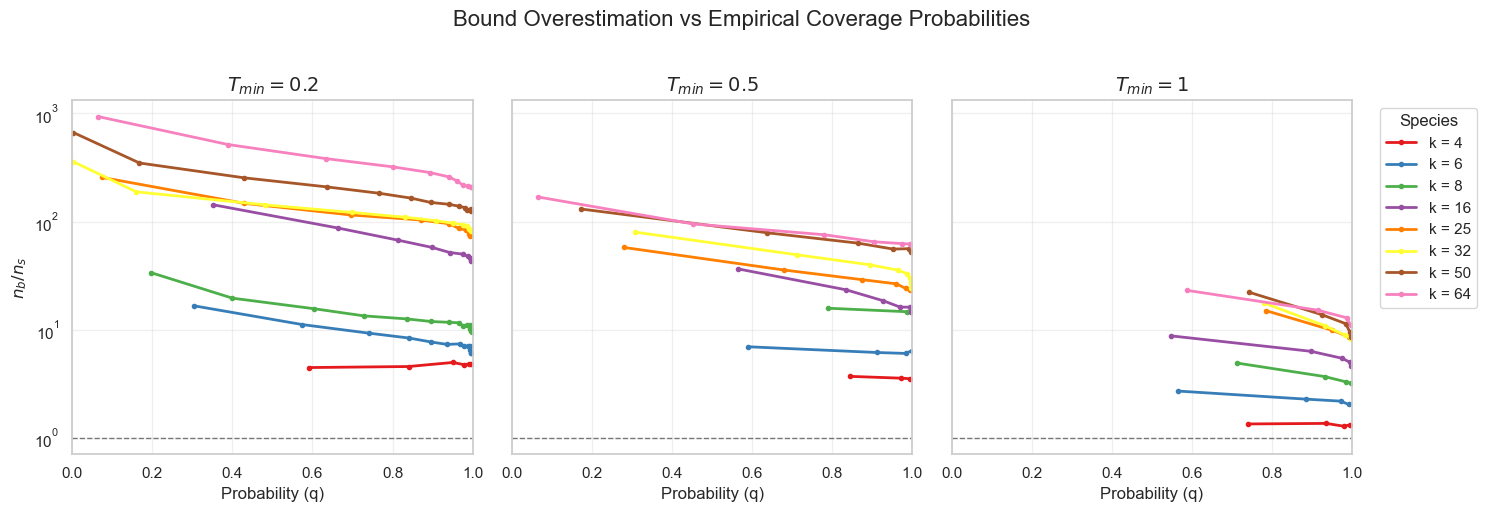

Results for Bound balanced


T_min=2, k=64: 100%|███████████████████████████████████████████████████████████████████| 40/40 [02:21<00:00,  3.54s/it]


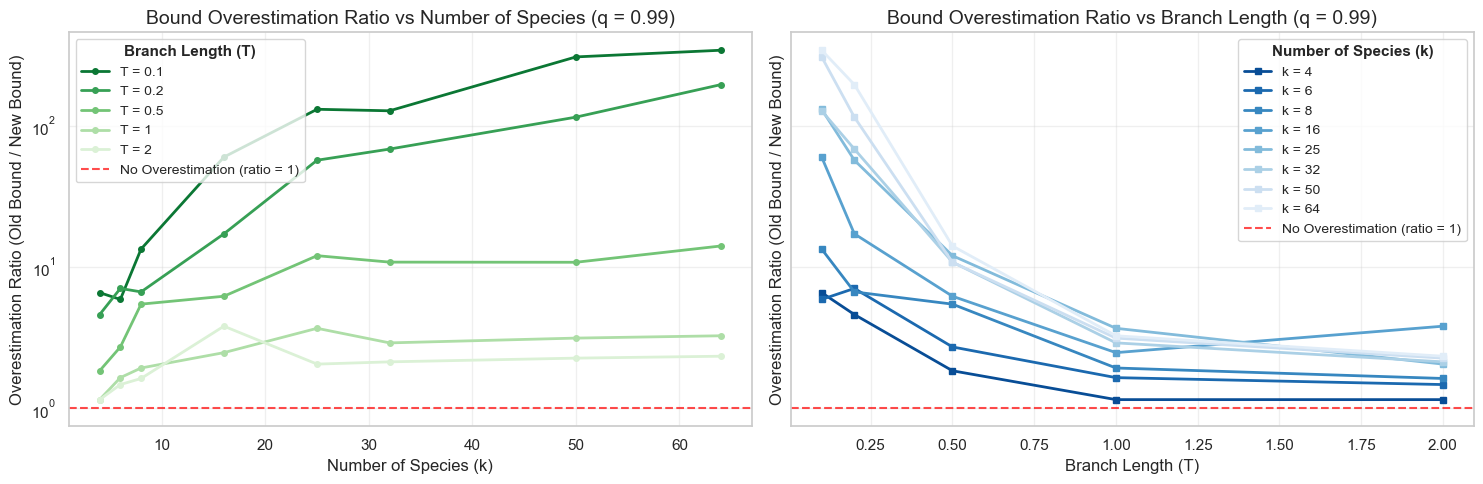

Plot saved to: C:\Users\zjmcn\OneDrive\Desktop\research\bipartition_covers\figures\overestimation_ratios\yule_tree_balanced_bound_vs_T_k.png


T_min=1, k=64: 100%|███████████████████████████████████████████████████████████████████| 24/24 [01:13<00:00,  3.04s/it]


Plot saved to: C:\Users\zjmcn\OneDrive\Desktop\research\bipartition_covers\figures\overestimation_ratios\yule_tree_balanced_bound_vs_q.png


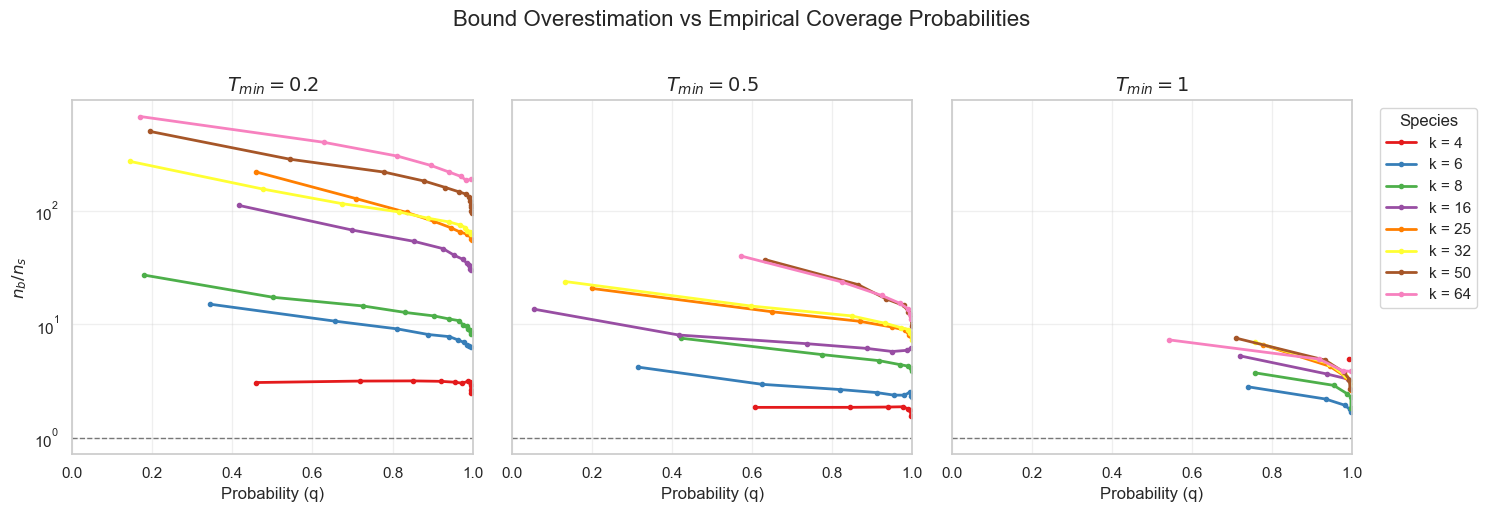

In [151]:
for name, bound in zip(names, all_bounds):
    print(f'Results for Bound {name}')
    savepath = figures_dir / 'overestimation_ratios' / f'yule_tree_{name}_bound_vs_T_k.png'
    make_overestimation_plot_vs_T_k(create_yule_tree, bound, k_vals, T_vals, 
                               num_samples=num_samples, max_genes=max_genes, log_plot=True, 
                               q = q,
                               figsize=(15, 5), savepath=savepath)
    savepath = figures_dir / 'overestimation_ratios' / f'yule_tree_{name}_bound_vs_q.png'
    make_overestimation_plot_vs_q(create_yule_tree, bound, k_vals, [0.2, 0.5, 1], 
                           num_samples=num_samples, max_genes=max_genes, log_plot=True, 
                           figsize=(15, 5), savepath=savepath)

Issues: Why is it only drawing a few dots?